# <center>PRÁCTICA 2: APRENDIZAJE SUPERVISADO (DengAI)<center>

**Nombre y apellidos: Rodrigo Andres Oyarzun Jimenez**

**Usuario VIU: royarzunj@student.universidadviu.com**

---
# Resumen
---

El presente trabajo se enfoca en el análisis exploratorio y predicción de casos de dengue mediante algorítmos supervisados en base a un conjunto de datos ambientales y meteorologícos asociados al dengue proporcionados por la competición de DengeAI. Los dataset con los que se trabajo son dengue_features_train_csv, dengue_features_test_csv y dengue_labels_train_csv los cuales se pueden descargar desde:

https://www.drivendata.org/competitions/44/dengai-predicting-disease-spread/data/

El proceso seguido se dividió en las siguientes etapas:
- Reexploración: estudio de valores nulos, posibles outliers y su tratamiento corresponciente. En esta etapa el también se realizaron análisis univariantes, análisis bivariantes, gráficas de evolución temporal y correlación de variables con nuestra variable objetivo (total_cases)
- predicción con hiperparámetros: se utilizaron distintos algoritmos de aprendizaje supervisado para poder predir la cantidad de casos de dengue por semana para distintas ciudad haciendo uso de hiperpámetros. Los algoritmos utilizados fueron:
  * Random Forest
  * Gradient Boosting
  * Support Vector
  * KNN
  * Light Gradient Boosting Machine
- Conclusiones: resultados obtenidos de los algoritmos y comparaciones

---
# Inicialización
---

In [30]:
# Imports generales
import pandas as pd
import io
from google.colab import files
import numpy as np
import time

seed = 42  # Semilla aleatoria arbitraria y constante a incluir en los algoritmos estocásticos para que los experimentos sean siempre reproducibles por el profesor.
# OJO: En los experimentos estocásticos que requieran varias iteraciones con distintas semillas, podéis incorporarla como seed+1, seed+2, etc.

def upload_files (index_fields=None):
  uploaded = files.upload()
  for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')), index_col = index_fields)

    return df

def download_predictions(test, pred_total_cases):
  file_name = "practica2_pred_" + time.strftime("%Y") + time.strftime("%m") + time.strftime("%d") + time.strftime("%H") + time.strftime("%M") + time.strftime("%S") + ".csv"
  predictions = pd.DataFrame({ 'city': test['city'], 'year': test['year'], 'weekofyear': test['weekofyear'], 'total_cases': pred_total_cases})
  with open(file_name, 'w') as f:
    predictions.to_csv(f, index = False)
  files.download(file_name)
  print("Downloaded " + file_name)

In [31]:
# Subir el conjunto de entrenamiento sin variable objetivo (dengue_features_train.csv)
train_feat = upload_files()
print(train_feat.shape)
train_feat.head()

Saving dengue_features_train.csv to dengue_features_train (1).csv
User uploaded file "dengue_features_train (1).csv" with length 287139 bytes
(1456, 24)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [32]:
# Subir la variable objetivo total_cases del conjunto de entrenamiento (dengue_labels_train.csv)
train_labels = upload_files()

# Unificar el conjunto de entrenamiento (características + variable objetivo)
train = pd.merge(train_feat,train_labels,on=['city', 'year', 'weekofyear'])
print(train.shape)
train.head()

Saving dengue_labels_train.csv to dengue_labels_train (1).csv
User uploaded file "dengue_labels_train (1).csv" with length 19582 bytes
(1456, 25)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6


In [33]:
# Subir el conjunto de test sin variable objetivo (dengue_features_test.csv)
test = upload_files()
print(test.shape)
test.head()

Saving dengue_features_test.csv to dengue_features_test (1).csv
User uploaded file "dengue_features_test (1).csv" with length 82465 bytes
(416, 24)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,2008,18,2008-04-29,-0.0189,-0.018900,0.102729,0.091200,78.60,298.492857,...,25.37,78.781429,78.60,15.918571,3.128571,26.528571,7.057143,33.3,21.7,75.2
1,sj,2008,19,2008-05-06,-0.0180,-0.012400,0.082043,0.072314,12.56,298.475714,...,21.83,78.230000,12.56,15.791429,2.571429,26.071429,5.557143,30.0,22.2,34.3
2,sj,2008,20,2008-05-13,-0.0015,NaN,0.151083,0.091529,3.66,299.455714,...,4.12,78.270000,3.66,16.674286,4.428571,27.928571,7.785714,32.8,22.8,3.0
3,sj,2008,21,2008-05-20,NaN,-0.019867,0.124329,0.125686,0.00,299.690000,...,2.20,73.015714,0.00,15.775714,4.342857,28.057143,6.271429,33.3,24.4,0.3
4,sj,2008,22,2008-05-27,0.0568,0.039833,0.062267,0.075914,0.76,299.780000,...,4.36,74.084286,0.76,16.137143,3.542857,27.614286,7.085714,33.3,23.3,84.1


---
# Reexploración
---

Ya que hemos cargado nuestros dataset, lo primero que haremos antes de realizar cualquier tipo de análisis profundo / gráfica o aplicar algún algorítmo es:
- Estudio de valores nulos para cada variable
- Imputación de nulos (mediana, promedio, eliminar fila, interpolación, etc)
- Estudio de Outliers

In [34]:
# Aplicaremos la función isnull para contar la cantidad de nulos que contiene cada una de nuestras variables y luego imprimeremos una tabla
# con la cantidad de nulos y el porccentaje que represetan para dicha variable. Luego, se elegirá el método para tratar los nulos encontrados
def analisis_nulos(df):
  nulos = df.isnull().sum() #Suma de nulos para las variables
  porcentaje = (nulos / len(df)) * 100 #Cálculo porcentual de nulos para las variables
  tabla = pd.DataFrame({"Nulos": nulos, "% Nulos": porcentaje.round(2)}) #Gerar la tabla con las variables, nulos y % nulos

  return tabla.sort_values(by = "Nulos", ascending = False) #Imprime la tabla generada ordenada por cantidad de nulos de mayor a menor

analisis_nulos(train)

,Nulos,% Nulos
ndvi_ne,194,13.32
ndvi_nw,52,3.57
station_avg_temp_c,43,2.95
station_diur_temp_rng_c,43,2.95
ndvi_se,22,1.51
ndvi_sw,22,1.51
station_precip_mm,22,1.51
station_max_temp_c,20,1.37
station_min_temp_c,14,0.96
precipitation_amt_mm,13,0.89


La tabla de valores nulos indica que la mayoría de las variables presentan menos de un 2% de nulos, seguidas por station_avg_tem_c y station_diur_temp_rng_c con un 2.95%, luego ndvi_nw con un 3.57% y finalmente ndvi_ne con un 13.32% siendo la variable con el mayor porccentaje de nulos de nuestro dataset train.

In [35]:
#Imputación de nulos
import numpy as np

#Usaremos solo nuestras columnas numéricas ya que las categóricas no presentan datos nulos
columnas_numericas_train = train.select_dtypes(include = [np.number]).columns.tolist()

#Función para interpolación
def interpolacion(datos):
  return datos.interpolate(method = "linear", limit_direction = "both")

for columna in columnas_numericas_train:
  train[columna] = train.groupby("city")[columna].transform(interpolacion)

#Corroboramos nuevamente si tenemos nulos en nuestro dataset
analisis_nulos(train)

,Nulos,% Nulos
city,0,0.0
year,0,0.0
weekofyear,0,0.0
week_start_date,0,0.0
ndvi_ne,0,0.0
ndvi_nw,0,0.0
ndvi_se,0,0.0
ndvi_sw,0,0.0
precipitation_amt_mm,0,0.0
reanalysis_air_temp_k,0,0.0


Nuestra tabla de nulos actualiza indica qué, luego de aplicar el método de interpolación según ciudad a cada variable, los datos faltes fueron tratados correctamente. Si bien para las variables que presentaban un porcentaje muy bajo de nulos se podría haber optado por eliminar la fila, se utilizó interpolación para evitar elimnar información del dataset la cual podría ser relevante para futuros estudios que realizaremos.

In [36]:
analisis_nulos(test)

,Nulos,% Nulos
ndvi_ne,43,10.34
station_diur_temp_rng_c,12,2.88
station_avg_temp_c,12,2.88
ndvi_nw,11,2.64
station_min_temp_c,9,2.16
station_precip_mm,5,1.20
station_max_temp_c,3,0.72
precipitation_amt_mm,2,0.48
reanalysis_relative_humidity_percent,2,0.48
reanalysis_precip_amt_kg_per_m2,2,0.48


Al igual que en nuestro dataset de train, revisamos si existían valores nulos en test. según nuestra tabla la variable ndvi_ne presentaba sobre 10% de nulos, mietras que station_diur_temp_rng_c, station_avg_temp_c, ndvi_nw, station_min_temp_c entre un 2-3%, station_precip_mm un 1.2% y el resto de las variables entre 0-1%. Al igual que en train, aplicamos interpolación para rellenar los valores nulos para seguir la misma metodología. Esto se hace principalmente por que los datos en ambos dataset para efectos de furutos modelos, deben contar con los mismos tratamientos para no generar distorsión en los resultados.

In [37]:
#Usaremos solo nuestras columnas numéricas ya que las categóricas no presentan datos nulos
columnas_numericas_test = test.select_dtypes(include = [np.number]).columns.tolist()

for columna in columnas_numericas_test:
  test[columna] = test.groupby("city")[columna].transform(interpolacion)

#Corroboramos nuevamente si tenemos nulos en nuestro dataset
analisis_nulos(test)

,Nulos,% Nulos
city,0,0.0
year,0,0.0
weekofyear,0,0.0
week_start_date,0,0.0
ndvi_ne,0,0.0
ndvi_nw,0,0.0
ndvi_se,0,0.0
ndvi_sw,0,0.0
precipitation_amt_mm,0,0.0
reanalysis_air_temp_k,0,0.0


Como se observa en nuestra tabla, ya no tenemos valores nulos ni en train ni el test, por lo cual podemos pasar al análisis de outliers.

In [38]:
#Estudio de Outliers train

#Usaremos solo nuestras columnas numéricas ya que las categóricas no presentan datos nulos
columnas_numericas_train = train.select_dtypes(include = [np.number]).columns.tolist()

if "total_cases" in columnas_numericas_train:
  columnas_numericas_train.remove("total_cases")

def contar_outliers(datos):
  #Cálculo de cuartiles e IQR
  Q1 = datos.quantile(0.25)
  Q3 = datos.quantile(0.75)
  IQR = Q3 - Q1

  #Cálculo de límite superior y límite inferior
  LI = Q1 - (3 * IQR)
  LS = Q3 + (3 * IQR)

  #Contar valores fuera de los límites definidos
  contar = ((datos < LI) | (datos > LS))
  suma_contar = contar.sum()

  return suma_contar

outliers_train = {}

for columna in columnas_numericas_train:
  outliers_ciudad = train.groupby("city")[columna].apply(contar_outliers)
  outliers_train[columna] = outliers_ciudad.to_dict()

df_outliers = pd.DataFrame(outliers_train).T
df_outliers

,iq,sj
year,0,0
weekofyear,0,0
ndvi_ne,0,4
ndvi_nw,0,4
ndvi_se,0,0
ndvi_sw,0,0
precipitation_amt_mm,0,9
reanalysis_air_temp_k,0,0
reanalysis_avg_temp_k,0,0
reanalysis_dew_point_temp_k,0,0


In [39]:
#Estudio de Outliers test

#Usaremos solo nuestras columnas numéricas ya que las categóricas no presentan datos nulos
columnas_numericas_test = test.select_dtypes(include = [np.number]).columns.tolist()

outliers_test = {}

for columna in columnas_numericas_test:
  outliers_ciudad_test = test.groupby("city")[columna].apply(contar_outliers)
  outliers_test[columna] = outliers_ciudad_test.to_dict()

df_outliers = pd.DataFrame(outliers_test).T
df_outliers

,iq,sj
year,0,0
weekofyear,0,0
ndvi_ne,0,5
ndvi_nw,0,2
ndvi_se,0,0
ndvi_sw,0,0
precipitation_amt_mm,0,1
reanalysis_air_temp_k,0,0
reanalysis_avg_temp_k,0,0
reanalysis_dew_point_temp_k,0,0


Dado que estamos analizando variables correspondientes a temperatura, precipitaciones y vegetación, las cuales pueden llegar a tomar valores muy extremos, para la revisión de outliers se decidió utilizar un umbral de +-3 * IQR para detectar solamente dichos valores extremos. podemos ver que para el caso de train la variable que más outliers prentó fue reanalysis_precip_amt_kg_per_m2 con un 2.4% y para la misma variable en el caso de test con un 1.7%. Dado que los porcentanjes son muy bajos, y para el resto de variables también hubo una cantidad reducida de outliers detectados, se opto por no eliminarlos.

0.01        0.05  \
                                      city                           
ndvi_ne                               iq      0.102029    0.136149   
                                      sj     -0.224726   -0.111550   
ndvi_nw                               iq      0.082737    0.126510   
                                      sj     -0.139810   -0.088854   
ndvi_se                               iq      0.094668    0.129649   
                                      sj      0.055751    0.088300   
ndvi_sw                               iq      0.101185    0.132116   
                                      sj      0.042081    0.079396   
precipitation_amt_mm                  iq      1.179500   11.338000   
                                      sj      0.000000    0.000000   
reanalysis_air_temp_k                 iq    295.160600  296.016714   
                                      sj    296.480000  297.171071   
reanalysis_avg_temp_k                 iq    296.019000  296.934643   
                                      sj    296.570000  297.310714   
reanalysis_dew_point_temp_k           iq    291.442514  292.876286   
                                      sj    290.888857  292.400000   
reanalysis_max_air_temp_k             iq    302.219000  303.600000   
                                      sj    298.900000  299.300000   
reanalysis_min_air_temp_k             iq    287.857000  289.795000   
                                      sj    294.000000  295.100000   
reanalysis_precip_amt_kg_per_m2       iq      1.438000    5.497000   
                                      sj      0.535000    2.600000   
reanalysis_relative_humidity_percent  iq     66.160929   74.713071   
                                      sj     70.643857   72.882500   
reanalysis_sat_precip_amt_mm          iq      1.179500   11.338000   
                                      sj      0.000000    0.000000   
reanalysis_specific_humidity_g_per_kg iq     13.232814   14.463286   
                                      sj     12.672643   13.884643   
reanalysis_tdtr_k                     iq      4.839429    5.512143   
                                      sj      1.657143    1.828571   
station_avg_temp_c                    iq     24.771250   26.132222   
                                      sj     23.944286   24.700000   
station_diur_temp_rng_c               iq      7.076000    8.100000   
                                      sj      4.676429    5.400000   
station_max_temp_c                    iq     31.216286   31.995000   
                                      sj     27.800000   28.300000   
station_min_temp_c                    iq     17.119000   18.790000   
                                      sj     18.900000   20.000000   
station_precip_mm                     iq      0.000000    0.800000   
                                      sj      0.000000    0.600000   
total_cases                           iq      0.000000    0.000000   
                                      sj      1.000000    3.000000   

                                                  0.25        0.50  \
                                      city                           
ndvi_ne                               iq      0.199511    0.263528   
                                      sj      0.004267    0.058129   
ndvi_nw                               iq      0.179530    0.232850   
                                      sj      0.016487    0.065950   
ndvi_se                               iq      0.194164    0.249764   
                                      sj      0.138936    0.176523   
ndvi_sw                               iq      0.203843    0.261871   
                                      sj      0.129457    0.166900   
precipitation_amt_mm                  iq     39.147500   60.490000   
                                      sj      0.000000   20.775000   
reanalysis_air_temp_k                 iq    297.092500  297.827857   
                                      sj    298.190714  299

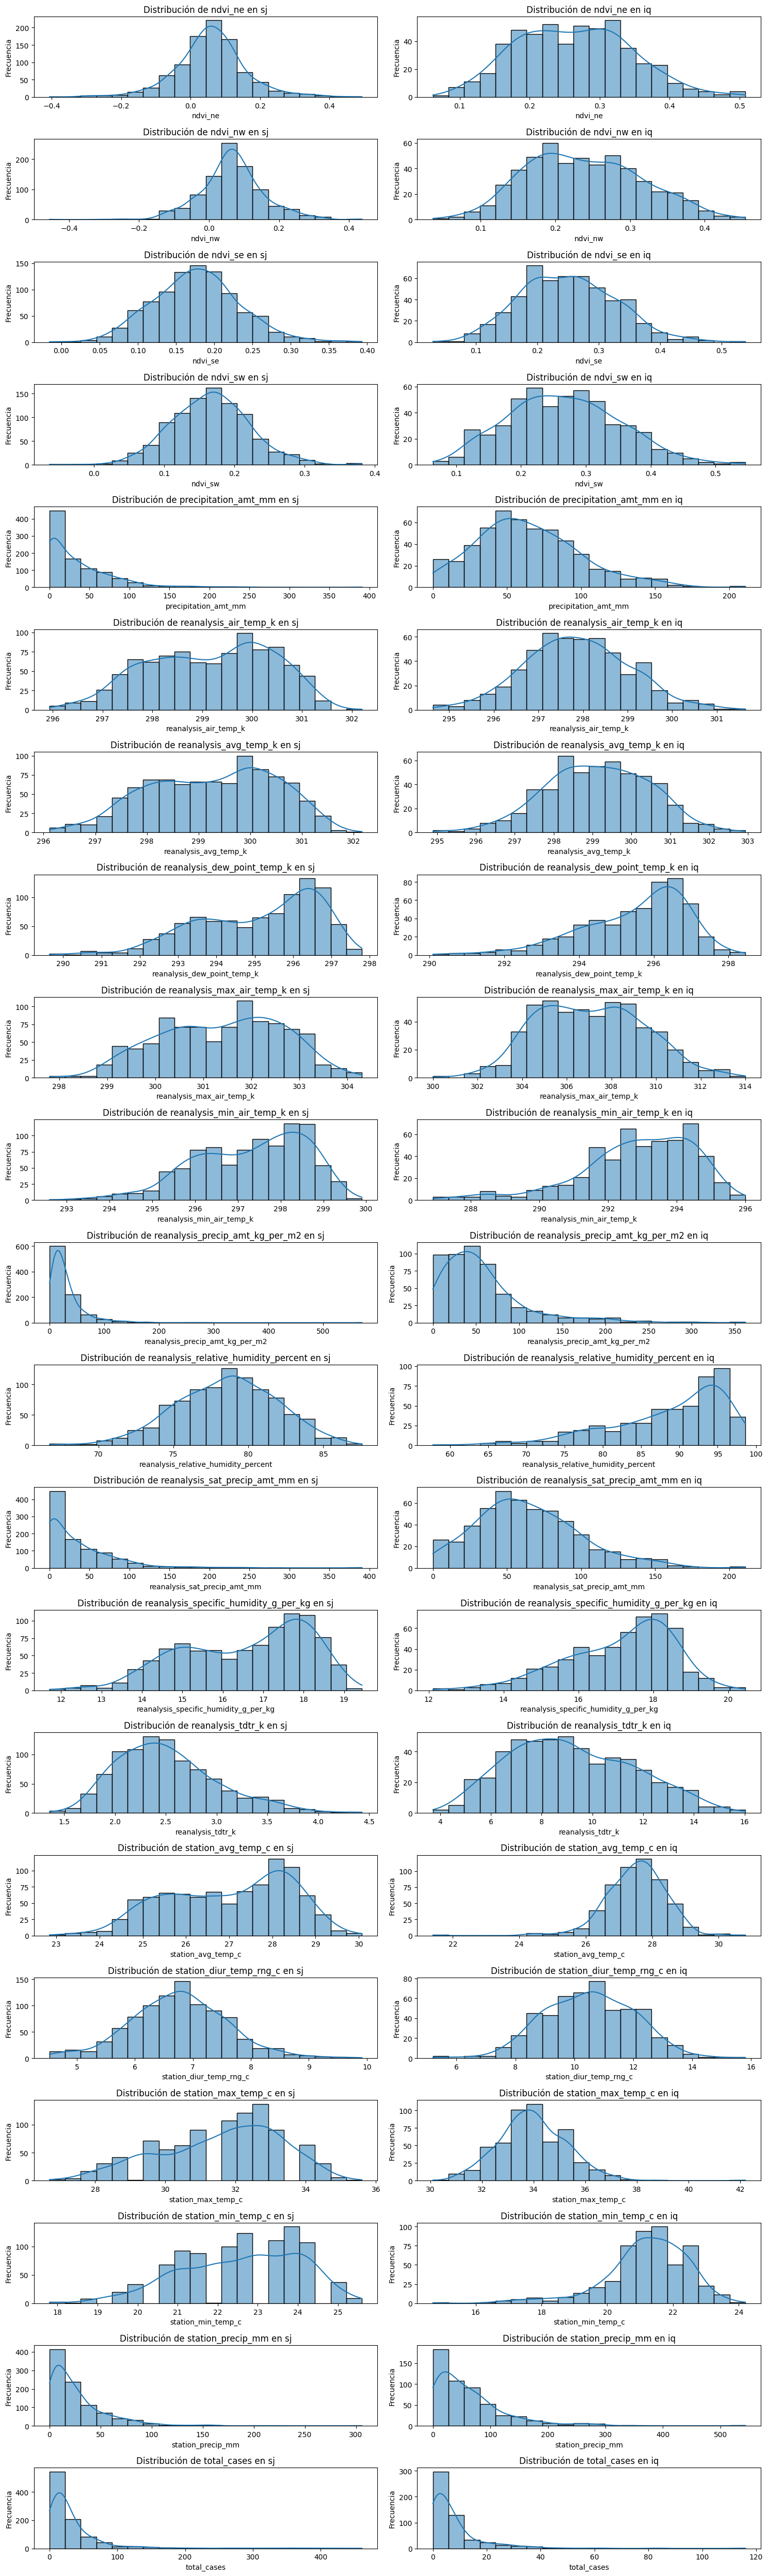

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

#Usaremos solo nuestras columnas numéricas ya que las categóricas no presentan datos nulos
columnas_numericas_train = train.select_dtypes(include = [np.number]).columns.tolist()
columnas_numericas_train.remove("year")
columnas_numericas_train.remove("weekofyear")

#Visualizaremos la tabla de percentiles para nuestro subconjunto de precipitación
percentiles = [1, 5, 25, 50, 75, 95, 99, 100]
tabla_percentiles = train.groupby("city")[columnas_numericas_train].quantile([p/100 for p in percentiles]).unstack(level=0)
display((tabla_percentiles).T)


#Visualizaremos los histogramas para nuesto subconjunot de precipitación
ciudad = train["city"].unique()
columnas_grafico = columnas_numericas_train
numero_variables = len(columnas_grafico)

plt.figure(figsize=(15, 50))
for i, columna in enumerate(columnas_grafico):
  for j, city in enumerate(ciudad):
    ax = plt.subplot(numero_variables, len(ciudad), i * len(ciudad) + j +1)
    data_ciudad = train[train["city"] == city]
    sns.histplot(data = data_ciudad, x = columna, ax = ax, bins = 20, kde = True)
    ax.set_title(f"Distribución de {columna} en {city}")
    ax.set_xlabel(columna)
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


Con nuestro análisis univariante observar como se distribuyen nuestras variables. se decto que varias se comportan como una distribución normal y otras presentan sesgo hacia la derecha o la izquiera, lo cual implica una mayor frecuenta en valores etremos de la distribución. Esto es importante ya que algunos alogoritmos supervisados son sensibles a los segos, por lo cual es interesante tener las variables detectadas para poder aplicar distintos métotos para tratar dichos sesgos. Las variables con sesgos impotantes detactadas fueron:

Sesgo a la derecha: reanalysis_tdtr_k, reanalysis_precip_amt_kg_per_m2 station_precip_mm, total_cases.

Sesgo a la izquiera: reanalysis_min_air_temp_k, reanalysis_specific_humidity_g_per_kg, reanalysis_dew_point_temp_k, station_avg_temp_c, reanalysis_relative_humidity_percent.


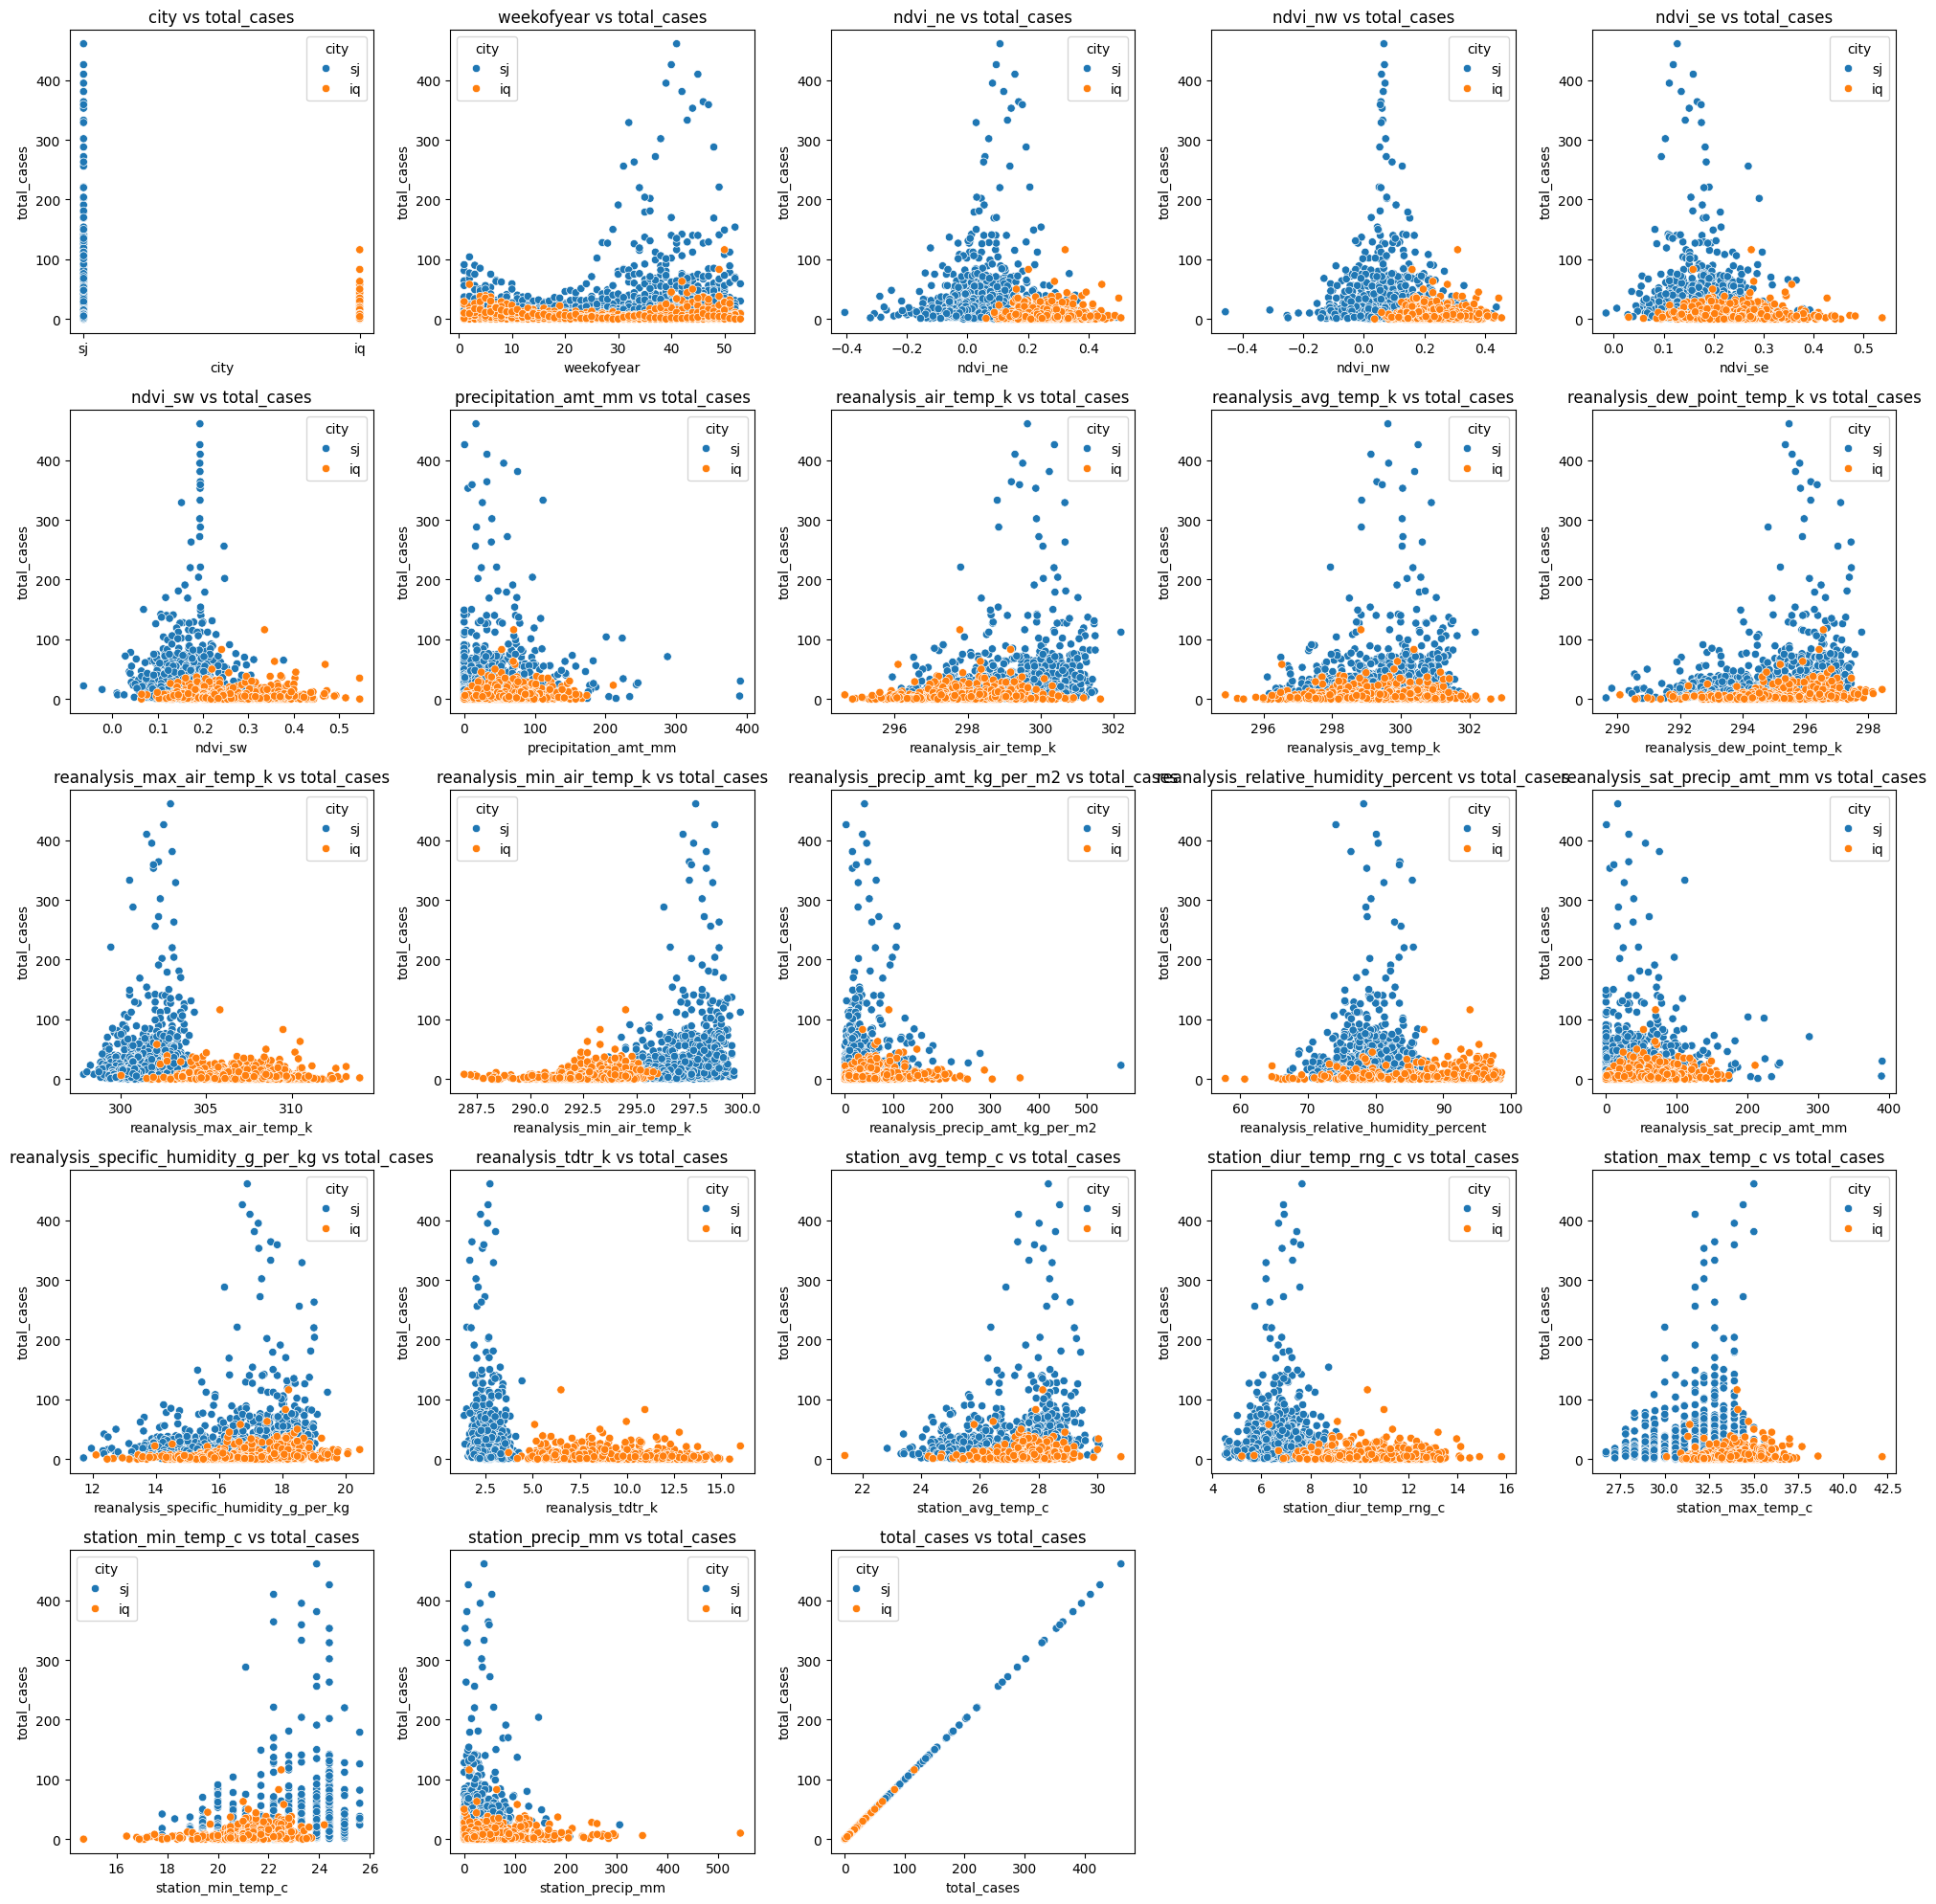

In [70]:
var_y = "total_cases"
columnas_excluir = ["week_start_date", "year"]
analisis_bivariante = train.drop(columns = columnas_excluir, errors = "ignore")
var_x = analisis_bivariante.columns
n_cols = 5
n_rows = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize = (4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, columna in enumerate(var_x):
  sns.scatterplot(data = train, x = columna, y = var_y, hue = "city", ax = axes[i])
  axes[i].set_title(f"{columna} vs {var_y}")
  axes[i].set_xlabel(columna)
  axes[i].set_ylabel(var_y)

for j in range(len(var_x), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Con nuestro análisis bivariante, si nos centramos en las gráficas asociadas a la variable total_cases podemos obervar que, respecto a las variables de precipitación, los casos más altos ocurriendo en semana que presentaban bajas precipitaciones. Para las variables realcionadas con la humedad, los casos más altos se encuentran asociados a semanas con humedad relativamente alta. En el caso de variables asociadas a la temperatura, los casos más altos ocurrían cuando las temperas eran elevadas. Finalmente, para las variables de vegetación, los casos más altos se presentaban en ausencia de vegetación (valores cercanos al 0 en el eje X). En el último gráfico de densidad se puede evidenciar una distribución asimétrica con un claro sesgo a la derecha.

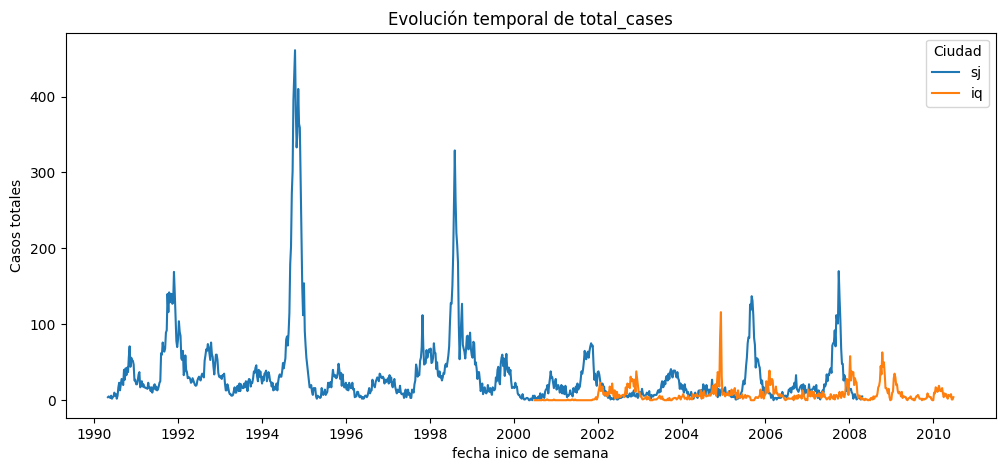

In [42]:
import matplotlib.dates as mdates

train["week_start_date"] = pd.to_datetime(train["week_start_date"])
train["year"] = train["week_start_date"].dt.year

plt.figure(figsize = (12,5))
ax = sns.lineplot(data = train, x = "week_start_date", y = "total_cases", hue = "city")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.title("Evolución temporal de total_cases")
plt.xlabel("fecha inico de semana")
plt.ylabel("Casos totales")
plt.legend(title = "Ciudad")
plt.show()


De nuestra gráfica temporal podemos decir que estamos frente a un patrón cíclico y estacional. Los picos más altos por semana llegaron a estar sobre 300 y  sobre 400 casos de dengue, semanas que podríamos catalogar como semanas de epidemia. Además, se observa como los pico que presenta iq son significativamente más bajos que los de sj, lo cual puede estar fuertemente relacionado a las diferencias climáticas entre ambas ciudad.

Dado que la columna city es categorita, aplicaremos una transformación para pasarla a binaria para facilitar futuros análisis, esto se aplciará tanto a train como a test:

In [43]:
from sklearn import preprocessing
lb = preprocessing.LabelBinarizer()

train_mod = train.copy()
test_mod = test.copy()
train_mod['city_bin'] = lb.fit_transform(train_mod['city'])
test_mod['city_bin'] = lb.transform(test_mod['city'])

train_mod.drop("city", axis = 1, inplace = True)
test_mod.drop("city", axis = 1, inplace = True)

In [44]:
print(lb.classes_)

['iq' 'sj']


In [45]:
train_mod.head()

,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,...,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,city_bin
0,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,...,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4,1
1,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,...,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5,1
2,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,...,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4,1
3,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,...,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3,1
4,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,...,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6,1


In [46]:
test_mod.head()

,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,city_bin
0,2008,18,2008-04-29,-0.01890,-0.018900,0.102729,0.091200,78.60,298.492857,298.550000,...,78.781429,78.60,15.918571,3.128571,26.528571,7.057143,33.3,21.7,75.2,1
1,2008,19,2008-05-06,-0.01800,-0.012400,0.082043,0.072314,12.56,298.475714,298.557143,...,78.230000,12.56,15.791429,2.571429,26.071429,5.557143,30.0,22.2,34.3,1
2,2008,20,2008-05-13,-0.00150,-0.016133,0.151083,0.091529,3.66,299.455714,299.357143,...,78.270000,3.66,16.674286,4.428571,27.928571,7.785714,32.8,22.8,3.0,1
3,2008,21,2008-05-20,0.02765,-0.019867,0.124329,0.125686,0.00,299.690000,299.728571,...,73.015714,0.00,15.775714,4.342857,28.057143,6.271429,33.3,24.4,0.3,1
4,2008,22,2008-05-27,0.05680,0.039833,0.062267,0.075914,0.76,299.780000,299.671429,...,74.084286,0.76,16.137143,3.542857,27.614286,7.085714,33.3,23.3,84.1,1


A continuación, analizaremos nuestra matriz de correlación para ver como se correlacionan nuestras variables entre ellas, y en específico, como se relacionan con nuestra variable objetivo total_cases.

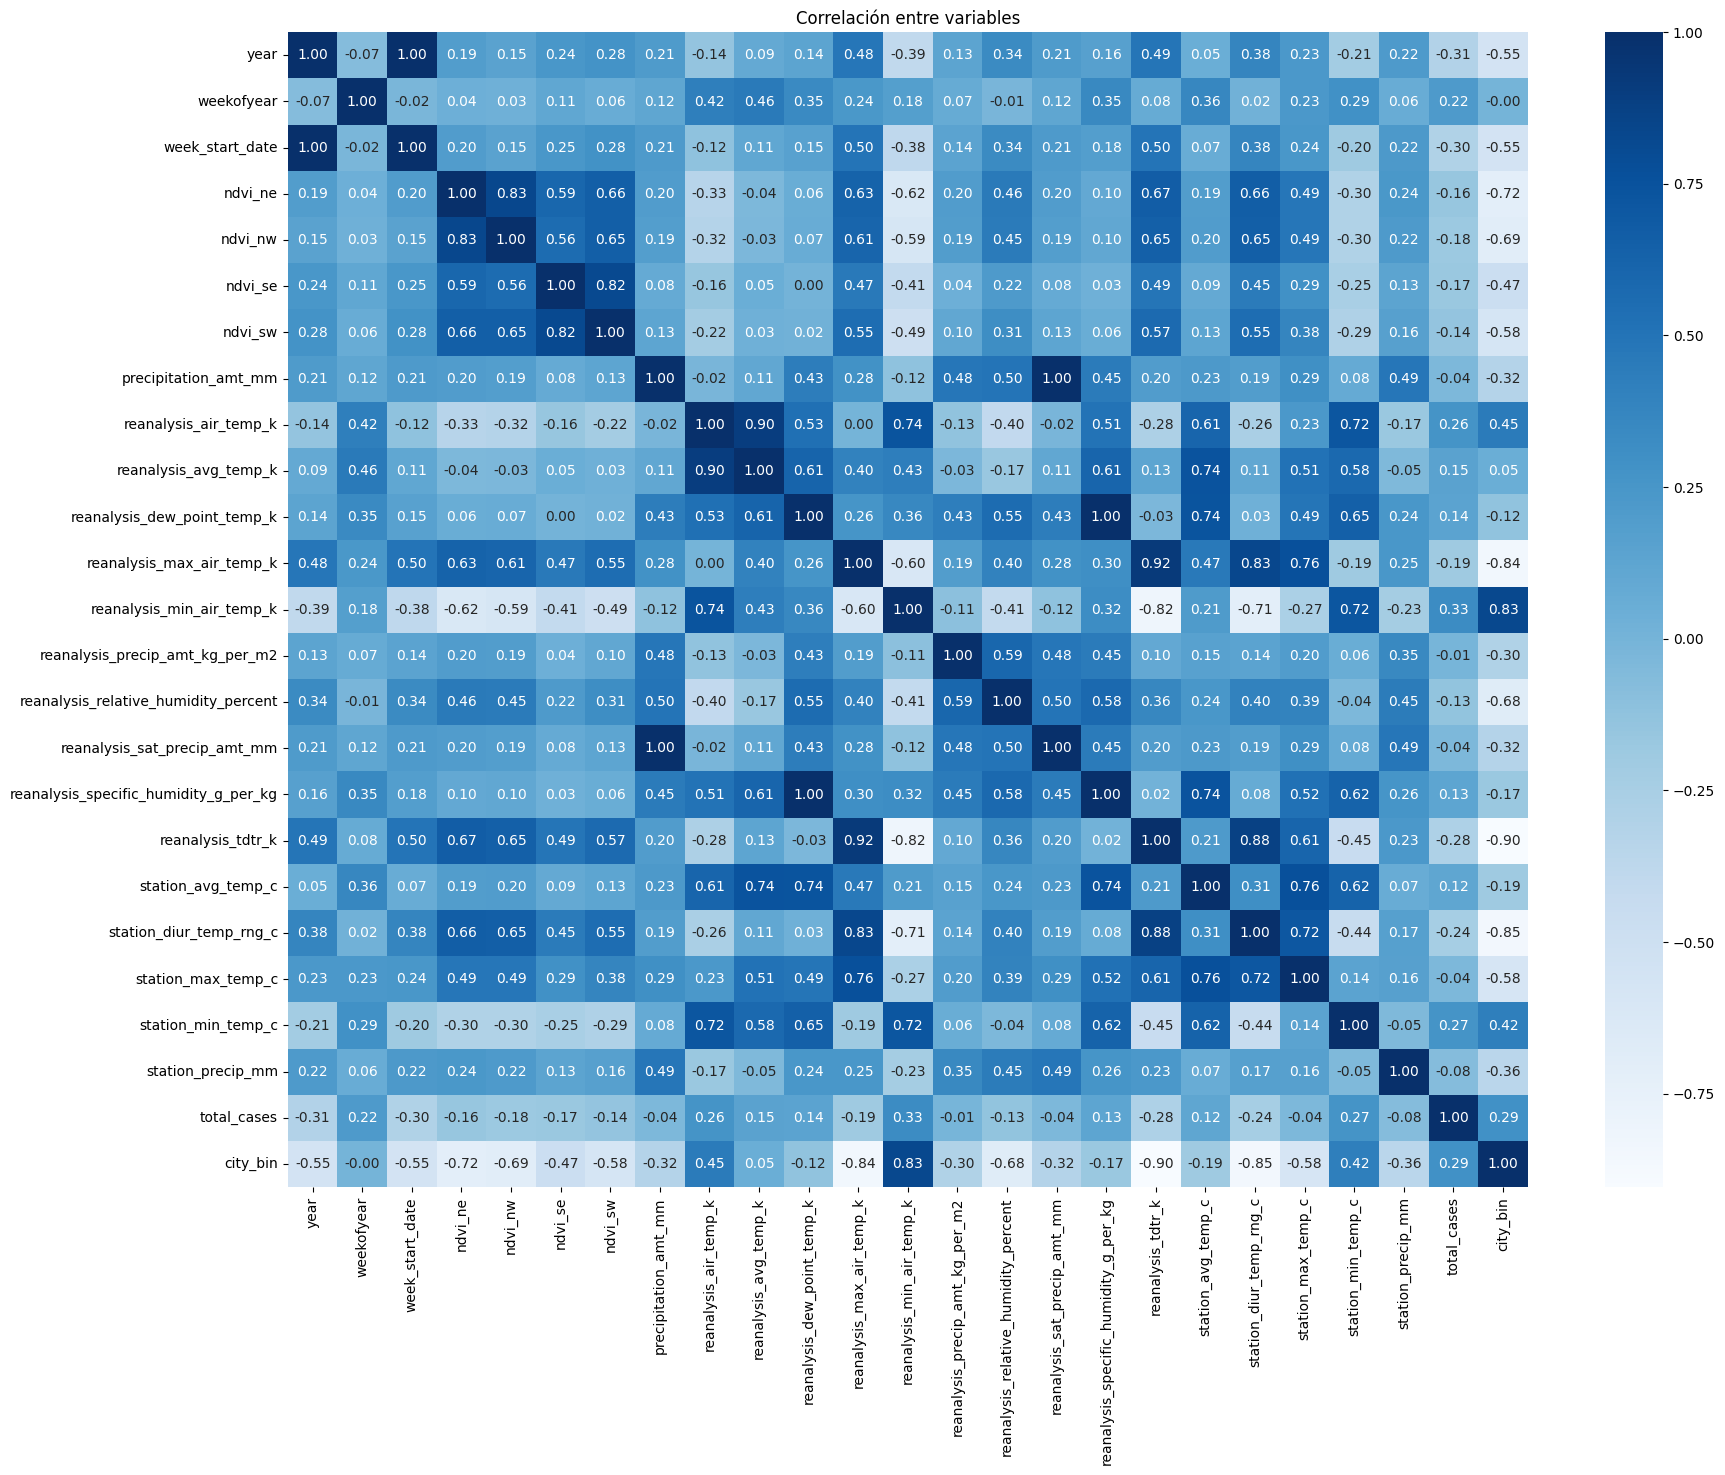

In [47]:
matriz_correlacion = train_mod.corr(method = "pearson")

plt.figure(figsize = (20, 15))
sns.heatmap(matriz_correlacion, annot = True, fmt = ".2f", cmap = "Blues")
plt.title("Correlación entre variables")
plt.show()

Podemos obervar que hay algunas variables que presentan mucha correlación entre ellas (mayor a 90%) tales como:
- precipitation_amt_mm / reanalysis_sat_precip_amt_mm: 1.00
- reanalysis_avg_temp_k / reanalysis_air_temp_k: 0.90
- reanalysis_dew_point_temp_k / reanalysis_specific_humidity_g_per_kg: 1.00
- reanalysis_max_air_temp_k / reanalysis_tdtr_k_ 0.92

Además, las variables que más se correlacionan con nuestra variable objetivo a primera vista son las varibles de tiempo, city_bin, station_min_temp_c, reanalysis_min_air_temp_k, reanalysis_air_temp_k.

A continuación, entrenaremos un modelo de randomforest básico para poder determinar cuales son las variables más importante para el modelo y que logran explicar el 92.5% de la varianza, dichas variables también serán utilizadas para la evaluación de todos los otros algoritmos.

In [48]:
columnas_final = [columna for columna in train_mod.columns if columna not in columnas_excluir]
columnas_final

['weekofyear',
 'ndvi_ne',
 'ndvi_nw',
 'ndvi_se',
 'ndvi_sw',
 'precipitation_amt_mm',
 'reanalysis_air_temp_k',
 'reanalysis_avg_temp_k',
 'reanalysis_dew_point_temp_k',
 'reanalysis_max_air_temp_k',
 'reanalysis_min_air_temp_k',
 'reanalysis_precip_amt_kg_per_m2',
 'reanalysis_relative_humidity_percent',
 'reanalysis_sat_precip_amt_mm',
 'reanalysis_specific_humidity_g_per_kg',
 'reanalysis_tdtr_k',
 'station_avg_temp_c',
 'station_diur_temp_rng_c',
 'station_max_temp_c',
 'station_min_temp_c',
 'station_precip_mm',
 'total_cases',
 'city_bin']

In [49]:
train_mod = train_mod[columnas_final]
train_mod.head()

,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,...,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,city_bin
0,18,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,...,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4,1
1,19,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,...,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5,1
2,20,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,...,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4,1
3,21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,...,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3,1
4,22,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,...,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6,1


In [50]:
test_sin_target = test_mod.drop("total_cases", axis=1, errors="ignore")
test_mod = test_sin_target[[columna for columna in columnas_final if columna in test_sin_target.columns]]
test_mod.head()

,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,city_bin
0,18,-0.01890,-0.018900,0.102729,0.091200,78.60,298.492857,298.550000,294.527143,301.1,...,78.781429,78.60,15.918571,3.128571,26.528571,7.057143,33.3,21.7,75.2,1
1,19,-0.01800,-0.012400,0.082043,0.072314,12.56,298.475714,298.557143,294.395714,300.8,...,78.230000,12.56,15.791429,2.571429,26.071429,5.557143,30.0,22.2,34.3,1
2,20,-0.00150,-0.016133,0.151083,0.091529,3.66,299.455714,299.357143,295.308571,302.2,...,78.270000,3.66,16.674286,4.428571,27.928571,7.785714,32.8,22.8,3.0,1
3,21,0.02765,-0.019867,0.124329,0.125686,0.00,299.690000,299.728571,294.402857,303.0,...,73.015714,0.00,15.775714,4.342857,28.057143,6.271429,33.3,24.4,0.3,1
4,22,0.05680,0.039833,0.062267,0.075914,0.76,299.780000,299.671429,294.760000,302.3,...,74.084286,0.76,16.137143,3.542857,27.614286,7.085714,33.3,23.3,84.1,1


In [51]:
X_train = train_mod.drop("total_cases", axis = 1)
y_train = train_mod["total_cases"]

                                 Variable  Importancia
10              reanalysis_min_air_temp_k     0.129439
0                              weekofyear     0.117747
4                                 ndvi_sw     0.069928
18                     station_max_temp_c     0.068157
15                      reanalysis_tdtr_k     0.060536
14  reanalysis_specific_humidity_g_per_kg     0.060119
2                                 ndvi_nw     0.056914
8             reanalysis_dew_point_temp_k     0.054973
11        reanalysis_precip_amt_kg_per_m2     0.044864
3                                 ndvi_se     0.043658
1                                 ndvi_ne     0.042958
20                      station_precip_mm     0.038814
16                     station_avg_temp_c     0.037829
7                   reanalysis_avg_temp_k     0.030661
12   reanalysis_relative_humidity_percent     0.025614
6                   reanalysis_air_temp_k     0.025176
17                station_diur_temp_rng_c     0.023884
9         

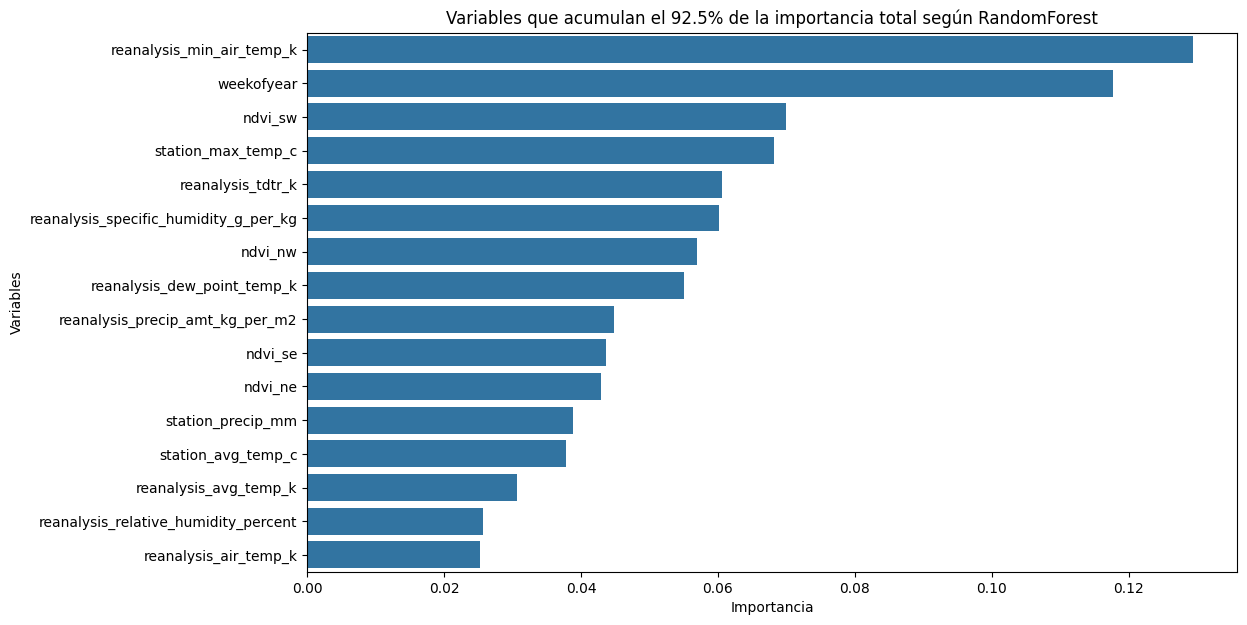

In [52]:
from sklearn.ensemble import RandomForestRegressor

rf_importancia = RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1)
rf_importancia.fit(X_train, y_train)

importancia = pd.DataFrame({"Variable": X_train.columns, "Importancia": rf_importancia.feature_importances_}).sort_values(by = "Importancia", ascending = False)
print(importancia.head(20))

importancia["Importancia_acum"] = importancia["Importancia"].cumsum()
umbral = 0.925
importancia_rf = importancia[importancia["Importancia_acum"] <= umbral]

vars_importantes = importancia_rf["Variable"].tolist()

plt.figure(figsize = (12, 7))
sns.barplot(x = "Importancia", y = "Variable", data = importancia_rf)
plt.title("Variables que acumulan el 92.5% de la importancia total según RandomForest")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.show()

In [53]:
X_train_RF = train_mod[vars_importantes]
X_test_RF = test_mod[vars_importantes]

Como podemos apreciar en nuestro gráfico, hemos definido un conjunto de 16 variables que representan un 92.5 de la varianza de nuestro dataset y que serán utilizadas para el entrenamiento de nuestos modelos haciendo uso de distintos algortimos supervisados. Además, podemos observar que las variables que más influyen en nuesto modelo son reanalysis_min_air_temp_k aproximandamente en un 13% y weekofyear en un 11.7%.

---
# Predicción
---

Para todos los modelos que ejecutemos en el apartado de predicción, haremos uso de randomizedsearch u gridsearch para buscar los hiperparámetros que optimicen los resultados que obtendremos con nuestros modelos.

Para nuestro primer modelo de Random Forest, aplicaremos un randomizedsearch con rangos amplios, iteraremos 100 veces y fijaremos la cross-validation en cuatro, esto con la finalidad de que el algoritmo tenga más combinaciones posibles para buscar los hiperparámetros. Una particularidad que tiene Random Forest, es que al ser un algortimo basado en árboles de decisión, no es necesario aplicar transformaciones ni normalización ya que no es sensible a estos efectos.

In [299]:
# MODELO RANDOM FOREST

from scipy.stats import randint as sp_randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

regressor_rf = RandomForestRegressor(random_state = 42)
regressor_rf

#RANDOMIZEDSEARCH
param_dist = {"n_estimators": [32, 64, 128, 256],
              "max_features": [1.0, "sqrt", "log2"],
              "max_depth": sp_randint(10, 25),
              "min_samples_split": sp_randint(2, 30),
              "min_samples_leaf": sp_randint(1, 30),
              "bootstrap": [True, False],
              "criterion": ["squared_error", "absolute_error"]}

rnd_regres_rf = RandomizedSearchCV(estimator = regressor_rf, param_distributions = param_dist,
                               n_iter = 100, cv = 4, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_rf.fit(X_train_RF, y_train)

def report(results, n_top=5): # Función para mostrar resultados
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

report(rnd_regres_rf.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: -17.420 (std: 8.464)
Parameters: {'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 14, 'max_features': 1.0, 'min_samples_leaf': 26, 'min_samples_split': 27, 'n_estimators': 32}

Model with rank: 2
Mean validation score: -17.432 (std: 8.513)
Parameters: {'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 19, 'max_features': 1.0, 'min_samples_leaf': 19, 'min_samples_split': 8, 'n_estimators': 32}

Model with rank: 3
Mean validation score: -17.481 (std: 8.480)
Parameters: {'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 19, 'max_features': 1.0, 'min_samples_leaf': 20, 'min_samples_split': 29, 'n_estimators': 32}

Model with rank: 4
Mean validation score: -17.623 (std: 8.458)
Parameters: {'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 18, 'max_features': 1.0, 'min_samples_leaf': 9, 'min_samples_split': 4, 'n_estimators': 128}

Model with rank: 5
Mean validation score: -17.677 (std: 8.531)
Par

In [300]:
rnd_regres_rf.best_params_

{'bootstrap': True,
 'criterion': 'absolute_error',
 'max_depth': 14,
 'max_features': 1.0,
 'min_samples_leaf': 26,
 'min_samples_split': 27,
 'n_estimators': 32}

Con los resultados obtenidos con nuestro con nuestro randomizedsearch, aplicaremos un gridsearcha acotando la busqueda a valores cercanos a los encontrados por randomizesearch:

In [316]:
#GRIDSEARCH
param_dist_GD_RF = {"max_features": [1.0],
              "n_estimators": [25, 35, 45],
              "max_depth": [12, 14, 16],
              "min_samples_split": [25, 27, 29],
              "min_samples_leaf": [23, 26, 29],
              "bootstrap": [True],
              "criterion": ["absolute_error"]}

grid_regres_rf = GridSearchCV(estimator = regressor_rf, param_grid = param_dist_GD_RF,cv = 4, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_rf.fit(X_train_RF, y_train)


GridSearchCV(cv=4, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['absolute_error'],
                         'max_depth': [12, 14, 16], 'max_features': [1.0],
                         'min_samples_leaf': [23, 26, 29],
                         'min_samples_split': [25, 27, 29],
                         'n_estimators': [25, 35, 45]},
             scoring='neg_mean_absolute_error')

In [317]:
report(grid_regres_rf.cv_results_, n_top = 10)

Model with rank: 1
Mean validation score: -17.373 (std: 8.431)
Parameters: {'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 12, 'max_features': 1.0, 'min_samples_leaf': 26, 'min_samples_split': 25, 'n_estimators': 25}

Model with rank: 1
Mean validation score: -17.373 (std: 8.431)
Parameters: {'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 12, 'max_features': 1.0, 'min_samples_leaf': 26, 'min_samples_split': 27, 'n_estimators': 25}

Model with rank: 1
Mean validation score: -17.373 (std: 8.431)
Parameters: {'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 12, 'max_features': 1.0, 'min_samples_leaf': 26, 'min_samples_split': 29, 'n_estimators': 25}

Model with rank: 1
Mean validation score: -17.373 (std: 8.431)
Parameters: {'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 14, 'max_features': 1.0, 'min_samples_leaf': 26, 'min_samples_split': 25, 'n_estimators': 25}

Model with rank: 1
Mean validation score: -17.373 (std: 8.431)
P

In [318]:
grid_regres_rf.best_estimator_

RandomForestRegressor(criterion='absolute_error', max_depth=12,
                      min_samples_leaf=26, min_samples_split=25,
                      n_estimators=25, random_state=42)

Ya teniendo los hiperparámetros que gridsearch encontró, vamos a calcular el MAE de validación:

In [319]:
mae_RF_CV = -grid_regres_rf.best_score_
print(f"MAE promedio de validación cruzada: {mae_RF_CV:.4f}")

MAE promedio de validación cruzada: 17.3732


A continuación, realizaremos la predicción con nuestro modelo y la dejaremos en el formato indicado para poder cargar el archivo en la página de la competición y obtener nuestro MAE test:

In [320]:
# choose the best
best_random = grid_regres_rf.best_estimator_
# fit and predict
y_pred = best_random.predict(X_test_RF)
y_pred

array([ 6.98,  6.32,  3.94,  3.7 ,  8.66,  8.2 ,  8.48,  4.68, 13.06,
       16.26, 12.74, 15.26, 18.48, 19.3 , 24.86, 38.2 , 32.4 , 36.22,
       36.82, 45.56, 43.8 , 36.42, 43.02, 47.84, 50.54, 41.4 , 42.9 ,
       34.18, 40.74, 40.78, 41.  , 29.66, 34.24, 31.3 , 26.7 , 23.02,
       16.3 , 25.08, 25.18, 23.74, 13.92, 22.16, 20.52, 18.02, 13.16,
       12.56,  7.14,  5.5 , 10.86,  6.42,  6.74,  6.82,  9.24,  8.08,
        9.6 ,  8.34, 11.12,  8.06, 10.14, 13.38,  9.36, 10.54, 16.44,
       16.82, 17.84, 19.28, 27.2 , 41.82, 35.16, 38.72, 37.48, 34.72,
       47.02, 60.16, 39.86, 45.6 , 39.02, 28.8 , 45.64, 26.24, 25.66,
       35.56, 41.56, 37.18, 23.8 , 41.  , 22.56, 32.72, 27.88, 22.9 ,
       25.88, 27.6 , 21.22, 17.32,  5.38, 11.4 , 14.44,  9.72,  8.92,
        8.96,  8.54,  7.74,  6.44,  9.64, 10.88, 10.26,  7.06, 14.38,
       12.54, 16.06, 13.5 , 15.9 , 15.1 , 13.16, 14.68, 17.34, 14.36,
       17.94, 18.22, 31.46, 31.1 , 45.92, 36.54, 42.96, 37.22, 44.58,
       33.1 , 43.22,

In [321]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred < 0] = 0
res

array([ 7,  6,  4,  4,  9,  8,  8,  5, 13, 16, 13, 15, 18, 19, 25, 38, 32,
       36, 37, 46, 44, 36, 43, 48, 51, 41, 43, 34, 41, 41, 41, 30, 34, 31,
       27, 23, 16, 25, 25, 24, 14, 22, 21, 18, 13, 13,  7,  6, 11,  6,  7,
        7,  9,  8, 10,  8, 11,  8, 10, 13,  9, 11, 16, 17, 18, 19, 27, 42,
       35, 39, 37, 35, 47, 60, 40, 46, 39, 29, 46, 26, 26, 36, 42, 37, 24,
       41, 23, 33, 28, 23, 26, 28, 21, 17,  5, 11, 14, 10,  9,  9,  9,  8,
        6, 10, 11, 10,  7, 14, 13, 16, 14, 16, 15, 13, 15, 17, 14, 18, 18,
       31, 31, 46, 37, 43, 37, 45, 33, 43, 40, 38, 34, 49, 40, 33, 27, 28,
       22, 20, 24, 28, 20, 17, 18, 20, 16, 17, 12, 14, 12, 10,  8,  8,  9,
       11, 10,  7,  7,  7,  7, 11, 10, 13, 12, 15, 18, 18, 14, 17, 16, 19,
       20, 28, 40, 37, 35, 43, 40, 38, 41, 41, 48, 36, 22, 35, 43, 26, 38,
       35, 20, 39, 32, 32, 24, 19, 18, 26, 18, 17, 12, 16, 10, 13,  8,  7,
        9,  9, 10, 12,  9,  8,  9,  9,  9,  8, 11, 14, 14, 14, 13, 18, 14,
       17, 22, 25, 29, 39

In [322]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251029173416.csv


MAE TEST 26.4111

Un mae de 26.4111 no es mal resultado. Vamos a realizar un segundo Random Fores aumentando la cantidad de iteraciones y disminuyendo el valor de cross-validation. Luego, repetiremos los mismos pasos anteriores hasta llegar a nuesto MAE TEST:

In [308]:
regressor_rf2 = RandomForestRegressor(random_state = 42)
regressor_rf2

#RANDOMIZEDSEARCH
param_dist = {"n_estimators": [64, 128, 256],
              "max_features": ["sqrt", "log2"],
              "max_depth": sp_randint(10, 25),
              "min_samples_split": sp_randint(2, 30),
              "min_samples_leaf": sp_randint(1, 30),
              "bootstrap": [True, False],
              "criterion": ["squared_error", "absolute_error"]}

rnd_regres_rf2 = RandomizedSearchCV(estimator = regressor_rf2, param_distributions = param_dist,
                               n_iter = 150, cv = 3, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_rf2.fit(X_train_RF, y_train)
report(rnd_regres_rf2.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: -20.853 (std: 11.627)
Parameters: {'bootstrap': False, 'criterion': 'absolute_error', 'max_depth': 14, 'max_features': 'log2', 'min_samples_leaf': 27, 'min_samples_split': 26, 'n_estimators': 64}

Model with rank: 2
Mean validation score: -20.947 (std: 11.529)
Parameters: {'bootstrap': False, 'criterion': 'absolute_error', 'max_depth': 21, 'max_features': 'log2', 'min_samples_leaf': 28, 'min_samples_split': 29, 'n_estimators': 64}

Model with rank: 3
Mean validation score: -21.053 (std: 11.572)
Parameters: {'bootstrap': False, 'criterion': 'absolute_error', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 28, 'min_samples_split': 17, 'n_estimators': 128}

Model with rank: 4
Mean validation score: -21.070 (std: 11.504)
Parameters: {'bootstrap': False, 'criterion': 'absolute_error', 'max_depth': 21, 'max_features': 'log2', 'min_samples_leaf': 23, 'min_samples_split': 6, 'n_estimators': 64}

Model with rank: 5
Mean validation score: -2

In [309]:
rnd_regres_rf2.best_params_

{'bootstrap': False,
 'criterion': 'absolute_error',
 'max_depth': 14,
 'max_features': 'log2',
 'min_samples_leaf': 27,
 'min_samples_split': 26,
 'n_estimators': 64}

In [310]:
#GRIDSEARCH
param_dist_GD_RF = {"max_features": ["log2"],
              "n_estimators": [55, 64, 75],
              "max_depth": [12, 14, 16],
              "min_samples_split": [25, 27, 29],
              "min_samples_leaf": [25, 27, 29],
              "bootstrap": [False],
              "criterion": ["absolute_error"]}

grid_regres_rf2 = GridSearchCV(estimator = regressor_rf2, param_grid = param_dist_GD_RF,cv = 3, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_rf2.fit(X_train_RF, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [False], 'criterion': ['absolute_error'],
                         'max_depth': [12, 14, 16], 'max_features': ['log2'],
                         'min_samples_leaf': [25, 27, 29],
                         'min_samples_split': [25, 27, 29],
                         'n_estimators': [55, 64, 75]},
             scoring='neg_mean_absolute_error')

In [311]:
grid_regres_rf2.best_estimator_

RandomForestRegressor(bootstrap=False, criterion='absolute_error', max_depth=12,
                      max_features='log2', min_samples_leaf=27,
                      min_samples_split=25, n_estimators=64, random_state=42)

In [312]:
mae_RF_CV2 = -grid_regres_rf2.best_score_
print(f"MAE promedio de validación cruzada: {mae_RF_CV2:.4f}")

MAE promedio de validación cruzada: 20.8531


In [313]:
# choose the best
best_random = grid_regres_rf2.best_estimator_
# fit and predict
y_pred2 = best_random.predict(X_test_RF)
y_pred2

array([ 7.8359375,  8.3203125,  6.984375 ,  7.3203125,  9.21875  ,
       10.8515625, 10.46875  ,  9.5859375, 13.609375 , 18.9375   ,
       14.4140625, 19.0703125, 15.4609375, 16.9296875, 32.1875   ,
       30.       , 23.2109375, 37.5625   , 33.703125 , 30.0234375,
       34.9765625, 35.0703125, 32.9609375, 44.1484375, 35.6328125,
       35.2890625, 39.6171875, 28.7421875, 39.2109375, 41.640625 ,
       39.40625  , 23.78125  , 21.984375 , 23.4453125, 15.3671875,
       15.421875 , 11.5078125, 18.3671875, 16.8828125, 20.140625 ,
       12.328125 , 21.703125 , 19.1171875, 18.6640625, 12.3984375,
       14.2578125, 11.9765625,  9.28125  , 11.1953125, 10.9921875,
        7.9453125,  9.4140625, 13.3515625, 12.59375  , 14.9296875,
       16.75     , 10.4296875,  9.5703125, 10.375    , 12.578125 ,
       11.25     , 14.59375  , 20.1328125, 18.890625 , 23.8359375,
       21.1484375, 25.546875 , 30.890625 , 27.453125 , 38.6640625,
       30.34375  , 35.578125 , 37.2890625, 48.265625 , 34.8906

In [314]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred2) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred2 < 0] = 0
res

array([ 8,  8,  7,  7,  9, 11, 10, 10, 14, 19, 14, 19, 15, 17, 32, 30, 23,
       38, 34, 30, 35, 35, 33, 44, 36, 35, 40, 29, 39, 42, 39, 24, 22, 23,
       15, 15, 12, 18, 17, 20, 12, 22, 19, 19, 12, 14, 12,  9, 11, 11,  8,
        9, 13, 13, 15, 17, 10, 10, 10, 13, 11, 15, 20, 19, 24, 21, 26, 31,
       27, 39, 30, 36, 37, 48, 35, 38, 31, 32, 33, 32, 26, 31, 35, 31, 25,
       34, 22, 27, 15, 13, 20, 16, 18, 13, 13, 11, 13, 10,  9,  9,  9,  9,
       10, 11, 12, 13, 11, 16, 14, 27, 27, 27, 27, 28, 31, 28, 29, 27, 29,
       39, 39, 38, 34, 30, 41, 36, 35, 37, 31, 29, 32, 44, 40, 29, 23, 20,
       17, 20, 20, 24, 19, 17, 16, 13, 14, 14, 11, 16, 14, 11,  9, 13, 11,
       10, 13, 12,  8, 14, 10, 16, 16, 17, 17, 23, 25, 25, 29, 29, 18, 31,
       30, 34, 32, 32, 36, 38, 37, 34, 35, 33, 38, 36, 25, 33, 35, 28, 33,
       31, 24, 38, 26, 25, 18, 16, 15, 23, 18, 21, 11, 17, 10, 13, 13,  8,
       18, 11, 10, 13,  9, 14, 16, 15, 13,  8, 13, 15, 18, 16, 16, 19, 18,
       29, 19, 33, 31, 32

In [315]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251029172310.csv


MAE TEST 26.5409

En comparación a nuestro primer MAE TEST, empeoro un poco pero no de manera significativa. Haciendo uso de los hiperparámetros obtenido por randomizeserach, haremos nuevamente un gridsearch pero modificaremos los valores de los hiperparámeros max_features por sqrt y criterion por squared_error ya que tieneden a mejor los resultados en comparación a log2 y absolute_error.

In [323]:
#GRIDSEARCH
param_dist_GD_RF = {"max_features": ["sqrt"],
              "n_estimators": [55, 64, 75],
              "max_depth": [12, 14, 16],
              "min_samples_split": [25, 27, 29],
              "min_samples_leaf": [25, 27, 29],
              "bootstrap": [True],
              "criterion": ["squared_error"]}

grid_regres_rf3 = GridSearchCV(estimator = regressor_rf2, param_grid = param_dist_GD_RF,cv = 3, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_rf3.fit(X_train_RF, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['squared_error'],
                         'max_depth': [12, 14, 16], 'max_features': ['sqrt'],
                         'min_samples_leaf': [25, 27, 29],
                         'min_samples_split': [25, 27, 29],
                         'n_estimators': [55, 64, 75]},
             scoring='neg_mean_absolute_error')

In [324]:
grid_regres_rf3.best_estimator_

RandomForestRegressor(max_depth=12, max_features='sqrt', min_samples_leaf=29,
                      min_samples_split=25, n_estimators=55, random_state=42)

In [325]:
mae_RF_CV3 = -grid_regres_rf3.best_score_
print(f"MAE promedio de validación cruzada: {mae_RF_CV3:.4f}")

MAE promedio de validación cruzada: 28.2412


In [326]:
# choose the best
best_random = grid_regres_rf3.best_estimator_
# fit and predict
y_pred2 = best_random.predict(X_test_RF)
y_pred2

array([12.33546988, 12.88019664, 13.28359348, 12.91104919, 15.09270656,
       15.730404  , 15.94775834, 24.55452677, 26.63606445, 26.76693916,
       26.53264434, 28.46803588, 30.23571693, 33.23304589, 58.73214567,
       54.34268451, 45.82175153, 60.12984684, 56.41344771, 57.05815874,
       61.58444261, 49.05338667, 53.20021669, 84.45521087, 50.15431432,
       50.39900363, 53.07892905, 39.70537803, 46.49128666, 44.21155079,
       62.94280373, 33.8016854 , 38.35736743, 42.18565687, 24.39820261,
       20.53597314, 18.77205503, 26.33645461, 23.90803721, 24.90680105,
       20.11025906, 24.51043267, 19.1593745 , 19.98341053, 14.96576752,
       15.61649779, 14.4787536 , 12.04058704, 16.84542512, 13.07371041,
       11.17767008, 11.60999074, 17.41113889, 13.77627038, 17.9647267 ,
       19.40378479, 20.37428739, 15.86003041, 17.71825863, 21.13777929,
       28.68764255, 28.66730711, 27.39648153, 35.04944505, 34.39967128,
       40.96149782, 40.65881237, 46.96377322, 53.79176183, 54.24

In [328]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred2) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred2 < 0] = 0
res

array([12, 13, 13, 13, 15, 16, 16, 25, 27, 27, 27, 28, 30, 33, 59, 54, 46,
       60, 56, 57, 62, 49, 53, 84, 50, 50, 53, 40, 46, 44, 63, 34, 38, 42,
       24, 21, 19, 26, 24, 25, 20, 25, 19, 20, 15, 16, 14, 12, 17, 13, 11,
       12, 17, 14, 18, 19, 20, 16, 18, 21, 29, 29, 27, 35, 34, 41, 41, 47,
       54, 54, 47, 56, 54, 57, 63, 75, 50, 53, 56, 49, 38, 50, 44, 49, 35,
       45, 33, 42, 22, 23, 26, 24, 23, 17, 17, 16, 18, 13, 14, 19, 22, 12,
       12, 17, 21, 27, 15, 25, 32, 40, 34, 36, 36, 38, 35, 38, 41, 40, 42,
       57, 55, 57, 64, 58, 53, 60, 53, 59, 55, 44, 51, 49, 46, 37, 38, 32,
       28, 36, 30, 38, 26, 25, 26, 22, 22, 22, 18, 18, 16, 13, 14, 14, 16,
       14, 16, 17, 11, 17, 13, 17, 19, 27, 28, 42, 40, 36, 36, 40, 30, 46,
       57, 50, 48, 60, 52, 51, 62, 41, 47, 54, 46, 43, 40, 41, 47, 39, 46,
       50, 45, 52, 44, 43, 29, 25, 22, 27, 21, 23, 18, 19, 14, 14, 15, 12,
       19, 15, 14, 15, 12, 18, 19, 21, 19, 15, 32, 25, 25, 28, 27, 30, 31,
       40, 37, 54, 56, 56

In [329]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251029173839.csv


MAE TEST 26.1034

Como podemos ver, nuestro MAE TEST mejoro significativamente (0.44 puntos). Volviendo a hacer uso del último randomizesearch, aplicaremos nuevamente un gridsearch pero aumentaremos la cantidad de n_estimators (árboles) para ver si nuestro modelo obtiene un mejor resultado.

In [384]:
#GRIDSEARCH
param_dist_GD_RF = {"max_features": ["sqrt"],
              "n_estimators": [80, 90, 100],
              "max_depth": [14, 15, 16],
              "min_samples_split": [23, 24, 25, 26, 27],
              "min_samples_leaf": [27, 28, 29, 30, 31],
              "bootstrap": [True],
              "criterion": ["squared_error"]}

grid_regres_rf4 = GridSearchCV(estimator = regressor_rf2, param_grid = param_dist_GD_RF,cv = 3, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_rf4.fit(X_train_RF, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['squared_error'],
                         'max_depth': [14, 15, 16], 'max_features': ['sqrt'],
                         'min_samples_leaf': [27, 28, 29, 30, 31],
                         'min_samples_split': [23, 24, 25, 26, 27],
                         'n_estimators': [80, 90, 100]},
             scoring='neg_mean_absolute_error')

In [385]:
grid_regres_rf4.best_estimator_

RandomForestRegressor(max_depth=14, max_features='sqrt', min_samples_leaf=29,
                      min_samples_split=23, n_estimators=90, random_state=42)

In [386]:
mae_RF_CV4 = -grid_regres_rf4.best_score_
print(f"MAE promedio de validación cruzada: {mae_RF_CV4:.4f}")

MAE promedio de validación cruzada: 28.7437


In [387]:
# choose the best
best_random = grid_regres_rf4.best_estimator_
# fit and predict
y_pred2 = best_random.predict(X_test_RF)
y_pred2

array([12.84839305, 12.60205921, 13.20811403, 12.13523281, 15.55952587,
       17.00895926, 16.39702111, 21.99112704, 27.5060183 , 27.78934933,
       27.79939172, 27.90417457, 30.7993435 , 33.96632133, 56.19909578,
       53.49528067, 44.02754431, 56.98800613, 57.94799305, 57.94654604,
       57.03431605, 50.60275665, 52.90288351, 78.04916521, 50.7372801 ,
       52.5736686 , 49.41588367, 40.02156761, 46.17128563, 43.9934486 ,
       61.60618862, 30.78103933, 36.23714244, 39.28902934, 24.32943486,
       21.15228402, 19.81556351, 25.63935718, 23.36334447, 24.92404151,
       19.91575565, 24.21504797, 19.88662028, 20.19415802, 15.16818211,
       15.53742913, 14.79775093, 12.07918145, 16.82967534, 13.31789278,
       11.16361014, 12.04069072, 17.21515113, 14.57709811, 20.27608606,
       19.84891604, 19.66029309, 16.24703687, 19.01152161, 20.64545198,
       31.15777768, 26.30190097, 30.48335179, 36.22150283, 36.36461829,
       40.4048726 , 40.95306903, 46.15829541, 51.41916782, 52.68

In [388]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred2) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred2 < 0] = 0
res

array([13, 13, 13, 12, 16, 17, 16, 22, 28, 28, 28, 28, 31, 34, 56, 53, 44,
       57, 58, 58, 57, 51, 53, 78, 51, 53, 49, 40, 46, 44, 62, 31, 36, 39,
       24, 21, 20, 26, 23, 25, 20, 24, 20, 20, 15, 16, 15, 12, 17, 13, 11,
       12, 17, 15, 20, 20, 20, 16, 19, 21, 31, 26, 30, 36, 36, 40, 41, 46,
       51, 53, 49, 57, 56, 59, 62, 76, 51, 52, 55, 50, 37, 50, 44, 48, 36,
       46, 35, 38, 23, 22, 27, 24, 23, 17, 18, 17, 19, 14, 14, 20, 21, 12,
       12, 16, 21, 26, 17, 24, 34, 39, 34, 35, 35, 37, 37, 38, 40, 39, 41,
       57, 56, 55, 68, 59, 54, 61, 54, 61, 57, 45, 52, 51, 48, 36, 37, 31,
       27, 33, 28, 35, 25, 26, 26, 22, 24, 21, 18, 18, 16, 14, 14, 15, 16,
       15, 16, 17, 11, 19, 14, 19, 21, 27, 27, 44, 38, 36, 35, 39, 30, 46,
       57, 48, 46, 60, 49, 51, 62, 41, 49, 53, 47, 45, 39, 42, 48, 40, 48,
       49, 42, 49, 40, 40, 29, 25, 22, 26, 21, 24, 17, 19, 14, 15, 17, 12,
       19, 16, 15, 17, 12, 20, 21, 22, 20, 16, 29, 25, 26, 28, 28, 30, 32,
       40, 37, 53, 56, 54

In [389]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251029191744.csv


MAE TEST 26.0697

Luego de realizar cuatro pruebas con Random Forest, hemos logrado dar con nuestro mejor resultado hasta el momento obteniendo un MAE TEST de 26.0697.

Ahora aplicaremos el algortimo Gradient Boosting, el cual al igual que Random Forest, se basa en árboles de decisión y por lo cual tampoco es necesario aplicar transformaciones ni normalización a las variables. La diferencia de Gradient Boosting vs Random Forest radica en la forma en como contruye los árboles, miestrans que Random Fores lo hace de manera paralela e independiente, Gradient Boosting lo hace de manera secuental y aditiva, por lo cual cada nuevo árbol va corrigiendo los errores del árbol anterior. Aplicaremos un randomizedsearch en un rando amplio para ver que hiperparámetros nos sugiere, usaremos inicialmente 100 iteraciones y un cross-validation de cuatro. Luego, aplicaremos un gridsearch con valores cercanos para ver si encontramos mejores hiperparámetros para finalmente hacer la predicción y obetener nuestro MAE TEST.

In [26]:
# Algortimo Gradiente Boosting
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform, randint

X_train_GBR = train_mod[vars_importantes].copy()
X_test_GBR = test_mod[vars_importantes].copy()
y_train_GBR = train_mod["total_cases"].copy()

regressor_gbr = GradientBoostingRegressor(random_state = 42)
regressor_gbr

#RANDOMIZEDSEARCH
param_dist = {"max_features": [1.0, "sqrt", "log2"],
              "n_estimators": randint(50, 400),
              "learning_rate": uniform(0.01, 0.5),
              "max_depth": randint(10, 25),
              "min_samples_split": randint(2, 30),
              "loss" : ['squared_error', 'absolute_error', 'huber', 'quantile'],
              "criterion": ['squared_error', 'friedman_mse']}

rnd_regres_gbr = RandomizedSearchCV(estimator = regressor_gbr, param_distributions = param_dist,
                               n_iter = 100, cv = 4, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_gbr.fit(X_train_GBR, y_train_GBR)

def report(results, n_top=5): # Función para mostrar resultados
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

report(rnd_regres_gbr.cv_results_, n_top = 5)


Model with rank: 1
Mean validation score: -18.634 (std: 8.999)
Parameters: {'criterion': 'squared_error', 'learning_rate': np.float64(0.05707849413428006), 'loss': 'absolute_error', 'max_depth': 23, 'max_features': 'sqrt', 'min_samples_split': 21, 'n_estimators': 253}

Model with rank: 2
Mean validation score: -18.716 (std: 8.578)
Parameters: {'criterion': 'friedman_mse', 'learning_rate': np.float64(0.1370818245348694), 'loss': 'absolute_error', 'max_depth': 11, 'max_features': 'sqrt', 'min_samples_split': 18, 'n_estimators': 153}

Model with rank: 3
Mean validation score: -18.774 (std: 8.829)
Parameters: {'criterion': 'squared_error', 'learning_rate': np.float64(0.020292247147901225), 'loss': 'absolute_error', 'max_depth': 17, 'max_features': 'sqrt', 'min_samples_split': 7, 'n_estimators': 241}

Model with rank: 4
Mean validation score: -19.075 (std: 9.170)
Parameters: {'criterion': 'squared_error', 'learning_rate': np.float64(0.0906106436270022), 'loss': 'absolute_error', 'max_depth'

In [27]:
rnd_regres_gbr.best_params_

{'criterion': 'squared_error',
 'learning_rate': np.float64(0.05707849413428006),
 'loss': 'absolute_error',
 'max_depth': 23,
 'max_features': 'sqrt',
 'min_samples_split': 21,
 'n_estimators': 253}

In [28]:
#GRIDSEARCH
param_dist_GD_GBR = {"max_features": ["sqrt"],
              "n_estimators": [200, 250, 300, 350],
              "max_depth": [15, 20, 25],
              "min_samples_split": [17, 19, 21, 23, 25],
              "learning_rate": [0.04, 0.05, 0.06, 0.07],
              "loss": ["absolute_error"],
              "criterion": ["squared_error"]}

grid_regres_gbr = GridSearchCV(estimator = regressor_gbr, param_grid = param_dist_GD_GBR,cv = 4, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_gbr.fit(X_train_GBR, y_train_GBR)

GridSearchCV(cv=4, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['squared_error'],
                         'learning_rate': [0.04, 0.05, 0.06, 0.07],
                         'loss': ['absolute_error'], 'max_depth': [15, 20, 25],
                         'max_features': ['sqrt'],
                         'min_samples_split': [17, 19, 21, 23, 25],
                         'n_estimators': [200, 250, 300, 350]},
             scoring='neg_mean_absolute_error')

In [29]:
grid_regres_gbr.best_estimator_

GradientBoostingRegressor(criterion='squared_error', learning_rate=0.05,
                          loss='absolute_error', max_depth=15,
                          max_features='sqrt', min_samples_split=23,
                          n_estimators=200, random_state=42)

In [30]:
mae_GBR_CV = -grid_regres_gbr.best_score_
print(f"MAE promedio de validación cruzada: {mae_GBR_CV:.4f}")

MAE promedio de validación cruzada: 18.2983


In [31]:
# choose the best
best_random = grid_regres_gbr.best_estimator_
# fit and predict
y_pred_gbr = best_random.predict(X_test_GBR)
y_pred_gbr

array([ 7.29198583,  7.26601896, 10.85224548,  8.40824275,  8.47012475,
       14.48036   , 11.01168978, 10.91734583, 14.5214765 , 17.47529439,
       15.27133714, 26.84315352, 16.12461604, 22.22756532, 28.5834452 ,
       40.5492517 , 13.22410664, 31.79790524, 59.11834184, 21.96613943,
       46.30725344, 31.56280151, 25.12304869, 58.64792041, 36.45853675,
       29.72881822, 34.77223531, 29.48406384, 35.98322727, 44.21509179,
       33.88849287, 22.73491803, 21.42468673, 15.20357311, 17.2298756 ,
       18.11977333, 10.81473552, 26.4158493 , 27.78798798, 27.54891623,
       17.6943132 , 18.03023933, 14.88386626, 13.6088841 ,  9.29271351,
        9.60804913, 11.37096659,  7.78576275, 14.96445468,  9.22587592,
        9.4118368 , 12.35414001, 12.34764606, 12.13059985, 14.95544084,
       13.03081041,  9.33732181,  8.32983542, 15.55746035, 12.90891302,
       21.78507431, 17.06160739, 25.2555024 , 24.76099456, 31.84571762,
       24.59670343, 39.63008828, 30.09182217, 35.39987463, 58.48

In [32]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred_gbr) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred_gbr < 0] = 0
res

array([ 7,  7, 11,  8,  8, 14, 11, 11, 15, 17, 15, 27, 16, 22, 29, 41, 13,
       32, 59, 22, 46, 32, 25, 59, 36, 30, 35, 29, 36, 44, 34, 23, 21, 15,
       17, 18, 11, 26, 28, 28, 18, 18, 15, 14,  9, 10, 11,  8, 15,  9,  9,
       12, 12, 12, 15, 13,  9,  8, 16, 13, 22, 17, 25, 25, 32, 25, 40, 30,
       35, 58, 41, 36, 29, 63, 46, 48, 31, 29, 36, 32, 19, 36, 37, 49, 21,
       32, 21, 48, 30, 23, 22, 28, 19, 16, 23, 17, 19, 14,  8, 18, 14, 10,
        8, 14, 14,  8,  9, 17, 20, 51, 42, 37, 24, 33, 57, 51, 45, 29, 38,
       68, 68, 58, 85, 64, 59, 46, 37, 45, 38, 31, 46, 40, 36, 28, 17, 22,
       22, 12, 15, 29, 21, 25, 16, 17, 20, 20, 11, 14, 16, 10, 19,  9, 11,
       14, 14, 10,  6, 14,  9, 14, 14, 23, 17, 47, 46, 33, 34, 34, 20, 57,
       33, 67, 28, 99, 40, 28, 33, 36, 35, 30, 35, 30, 26, 38, 28, 21, 38,
       30, 35, 53, 35, 34, 26, 21, 22, 27, 21, 21, 12, 15,  9, 10, 10,  6,
       16, 10, 12, 13, 10, 17, 25, 14, 44, 11, 16, 15, 44, 31, 15, 17, 16,
       21, 25, 33, 20, 25

In [33]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251030095655.csv


MAE TEST 26.3197

Realizaremos una segunda iteración aumentando los rangos de valores para n_estimators y learning_rate y disminuyendo el rango para max_depth. Además, mantendremos la cantidad de iteraciones pero ajustaremos el cross-validation a tres.

In [34]:
regressor_gbr2 = GradientBoostingRegressor(random_state = 42)
regressor_gbr2

#RANDOMIZEDSEARCH
param_dist = {"max_features": ["sqrt", "log2"],
              "n_estimators": randint(250, 500),
              "learning_rate": uniform(0.01, 0.15),
              "max_depth": randint(3, 8),
              "min_samples_split": randint(2, 20),
              "loss" : ['squared_error', 'absolute_error', 'huber'],
              "criterion": ['squared_error', 'friedman_mse']}

rnd_regres_gbr2 = RandomizedSearchCV(estimator = regressor_gbr2, param_distributions = param_dist,
                               n_iter = 100, cv = 3, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_gbr2.fit(X_train_GBR, y_train_GBR)
report(rnd_regres_gbr2.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: -20.706 (std: 11.270)
Parameters: {'criterion': 'friedman_mse', 'learning_rate': np.float64(0.033465556400662906), 'loss': 'absolute_error', 'max_depth': 3, 'max_features': 'log2', 'min_samples_split': 14, 'n_estimators': 366}

Model with rank: 2
Mean validation score: -20.808 (std: 11.265)
Parameters: {'criterion': 'squared_error', 'learning_rate': np.float64(0.04218836795625612), 'loss': 'absolute_error', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 19, 'n_estimators': 284}

Model with rank: 3
Mean validation score: -20.841 (std: 11.531)
Parameters: {'criterion': 'squared_error', 'learning_rate': np.float64(0.016816957051218683), 'loss': 'absolute_error', 'max_depth': 6, 'max_features': 'log2', 'min_samples_split': 9, 'n_estimators': 371}

Model with rank: 4
Mean validation score: -20.860 (std: 11.466)
Parameters: {'criterion': 'squared_error', 'learning_rate': np.float64(0.013087674144370367), 'loss': 'absolute_error', 'max_d

In [38]:
rnd_regres_gbr2.best_params_

{'criterion': 'friedman_mse',
 'learning_rate': np.float64(0.033465556400662906),
 'loss': 'absolute_error',
 'max_depth': 3,
 'max_features': 'log2',
 'min_samples_split': 14,
 'n_estimators': 366}

In [40]:
#GRIDSEARCH
param_dist_GD_GBR = {"max_features": ["log2"],
              "n_estimators": [350, 400, 450],
              "max_depth": [3, 4, 5],
              "min_samples_split": [13, 14, 15],
              "learning_rate": [0.03, 0.035, 0.04],
              "loss": ["absolute_error"],
              "criterion": ["friedman_mse"]}

grid_regres_gbr2 = GridSearchCV(estimator = regressor_gbr2, param_grid = param_dist_GD_GBR,cv = 3, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_gbr2.fit(X_train_GBR, y_train_GBR)

GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['friedman_mse'],
                         'learning_rate': [0.03, 0.035, 0.04],
                         'loss': ['absolute_error'], 'max_depth': [3, 4, 5],
                         'max_features': ['log2'],
                         'min_samples_split': [13, 14, 15],
                         'n_estimators': [350, 400, 450]},
             scoring='neg_mean_absolute_error')

In [41]:
grid_regres_gbr2.best_estimator_

GradientBoostingRegressor(learning_rate=0.035, loss='absolute_error',
                          max_depth=5, max_features='log2',
                          min_samples_split=15, n_estimators=350,
                          random_state=42)

In [42]:
mae_GBR_CV2 = -grid_regres_gbr2.best_score_
print(f"MAE promedio de validación cruzada: {mae_GBR_CV2:.4f}")

MAE promedio de validación cruzada: 20.5480


In [43]:
# choose the best
best_random = grid_regres_gbr2.best_estimator_
# fit and predict
y_pred_gbr2 = best_random.predict(X_test_GBR)
y_pred_gbr2

array([ 6.82829535,  5.70479703,  6.3627855 ,  6.25877049, 10.67136348,
        8.63226897,  7.74728482,  7.60693577, 11.79551837, 16.32795   ,
       13.58097813, 20.37109842, 18.48367245, 21.46671365, 26.72448036,
       41.97140274, 20.08170622, 29.44870165, 44.1059174 , 29.62173036,
       39.65414569, 32.48032591, 25.19844403, 38.39104186, 31.70748022,
       30.48958577, 34.73653186, 27.98324346, 32.046344  , 36.8250705 ,
       33.31288954, 22.48717956, 18.92367357, 18.45429504, 15.52182029,
       16.6655878 , 12.05077555, 20.21725231, 17.2877623 , 19.95584339,
       14.56999886, 20.49976414, 15.60326948, 14.33231632, 11.11947874,
       11.93854478,  7.90785511,  4.2315057 , 10.97192809,  9.10401113,
        4.58157451,  8.77604056, 11.93911622, 10.0603208 , 11.68184154,
       12.07044645, 10.66685456, 10.20668603, 10.11904176, 12.47144298,
       10.16065744, 32.52849969, 22.9033711 , 27.29806567, 43.23897416,
       27.43931436, 44.56516673, 23.40387323, 24.53089907, 57.99

In [44]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred_gbr2) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred_gbr2 < 0] = 0
res

array([ 7,  6,  6,  6, 11,  9,  8,  8, 12, 16, 14, 20, 18, 21, 27, 42, 20,
       29, 44, 30, 40, 32, 25, 38, 32, 30, 35, 28, 32, 37, 33, 22, 19, 18,
       16, 17, 12, 20, 17, 20, 15, 20, 16, 14, 11, 12,  8,  4, 11,  9,  5,
        9, 12, 10, 12, 12, 11, 10, 10, 12, 10, 33, 23, 27, 43, 27, 45, 23,
       25, 58, 44, 33, 27, 34, 45, 50, 34, 28, 36, 21, 19, 26, 30, 32, 24,
       39, 21, 25, 21, 16, 20, 19, 16, 12, 17, 13, 14,  8,  6, 10, 12,  8,
        6, 10, 11, 11,  5, 16, 13, 23, 27, 25, 17, 25, 33, 37, 27, 27, 30,
       66, 41, 49, 63, 55, 44, 36, 34, 39, 36, 29, 26, 33, 42, 25, 19, 22,
       16, 13, 16, 23, 24, 17, 14, 15, 15, 15, 11, 13, 13, 11,  7,  8, 10,
       12, 11, 11,  3,  9,  8, 11, 11, 14, 15, 26, 24, 19, 21, 24, 19, 35,
       29, 41, 27, 36, 35, 28, 32, 32, 39, 29, 34, 30, 22, 38, 30, 25, 32,
       26, 22, 38, 25, 27, 21, 19, 17, 22, 15, 21, 11, 15, 10, 13, 12,  8,
       15, 10, 11, 11,  8, 12, 12, 11, 12,  8, 16, 28, 23, 27, 36, 19, 17,
       24, 21, 31, 31, 31

In [45]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251030102505.csv


MAE TEST 26.5769

Dado que MAE TEST empeoró, volveremos a iterar sobre los valores encontratos por randomize pero ajustaremos max_feature a sqrt ya que generalmente otorga mejores resultados que log2 y aumentaremos max_deph

In [74]:
#GRIDSEARCH
param_dist_GD_GBR = {"max_features": ["sqrt"],
              "n_estimators": [250, 300, 350],
              "max_depth": [18, 19, 20],
              "min_samples_split": [16, 17, 18],
              "learning_rate": [0.01, 0.02, 0.03],
              "loss": ["absolute_error"],
              "criterion": ["friedman_mse"]}

grid_regres_gbr3 = GridSearchCV(estimator = regressor_gbr2, param_grid = param_dist_GD_GBR,cv = 3, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_gbr3.fit(X_train_GBR, y_train_GBR)

GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['friedman_mse'],
                         'learning_rate': [0.01, 0.02, 0.03],
                         'loss': ['absolute_error'], 'max_depth': [18, 19, 20],
                         'max_features': ['sqrt'],
                         'min_samples_split': [16, 17, 18],
                         'n_estimators': [250, 300, 350]},
             scoring='neg_mean_absolute_error')

In [75]:
grid_regres_gbr3.best_estimator_

GradientBoostingRegressor(learning_rate=0.01, loss='absolute_error',
                          max_depth=20, max_features='sqrt',
                          min_samples_split=17, n_estimators=250,
                          random_state=42)

In [76]:
mae_GBR_CV3 = -grid_regres_gbr2.best_score_
print(f"MAE promedio de validación cruzada: {mae_GBR_CV3:.4f}")

MAE promedio de validación cruzada: 20.7943


In [77]:
# choose the best
best_random = grid_regres_gbr2.best_estimator_
# fit and predict
y_pred_gbr3 = best_random.predict(X_test_GBR)
y_pred_gbr3

array([ 8.49948627,  7.94530437, 10.16638128,  9.69228966, 12.11908444,
       14.29884175, 10.00218495, 16.08840573, 14.88405736, 22.89039461,
       15.15746891, 24.44376044, 17.93557671, 16.78311208, 24.6653273 ,
       34.09673179, 16.38876255, 27.94961332, 36.47708119, 25.46249104,
       38.06903978, 29.44747093, 30.603444  , 52.59238743, 35.48097104,
       30.70870658, 42.05069892, 23.07804246, 40.53580077, 43.65413443,
       30.85421736, 23.22504543, 18.8951611 , 20.42266387, 14.87630594,
       17.522016  , 11.66427016, 25.26716405, 20.65815555, 29.38689599,
       12.92667705, 19.53431203, 16.65921174, 15.5416581 , 11.40138626,
       13.16918105, 10.94457457,  7.80598685, 11.51026358,  8.16113991,
        7.78340077, 11.56603502, 14.07971851, 12.37312553, 11.71258504,
       11.8424152 , 11.06836575, 10.8312576 , 13.62542758, 12.3437288 ,
       11.81808058, 19.7370103 , 23.33389672, 22.90055667, 30.78694071,
       26.93765822, 28.65063095, 28.4087177 , 24.79192887, 46.22

In [78]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred_gbr3) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred_gbr3 < 0] = 0
res

array([ 8,  8, 10, 10, 12, 14, 10, 16, 15, 23, 15, 24, 18, 17, 25, 34, 16,
       28, 36, 25, 38, 29, 31, 53, 35, 31, 42, 23, 41, 44, 31, 23, 19, 20,
       15, 18, 12, 25, 21, 29, 13, 20, 17, 16, 11, 13, 11,  8, 12,  8,  8,
       12, 14, 12, 12, 12, 11, 11, 14, 12, 12, 20, 23, 23, 31, 27, 29, 28,
       25, 46, 34, 34, 23, 49, 44, 43, 31, 20, 39, 29, 17, 26, 34, 40, 24,
       36, 24, 39, 25, 19, 19, 25, 17, 14, 17, 15, 20, 12,  9, 11, 10, 11,
        8, 13, 16, 11,  9, 16, 18, 42, 38, 30, 23, 31, 38, 49, 34, 29, 32,
       51, 47, 53, 54, 36, 46, 35, 34, 40, 29, 24, 30, 35, 36, 26, 19, 21,
       19, 14, 18, 27, 20, 23, 17, 16, 15, 16, 12, 14, 13, 10, 11,  9, 11,
       14, 13, 11,  7, 14, 11, 15, 14, 14, 20, 34, 45, 25, 30, 28, 19, 47,
       31, 44, 25, 54, 34, 31, 31, 32, 30, 26, 34, 31, 25, 36, 26, 21, 34,
       23, 24, 45, 25, 29, 27, 21, 19, 24, 16, 21, 11, 16,  9, 12, 10,  7,
       13, 11, 13, 12, 10, 15, 13, 17, 10,  9, 14, 20, 25, 19, 21, 19, 16,
       27, 23, 31, 25, 23

In [79]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251030114705.csv


MAE TEST 26.6995

Luego de realizar cuatro pruebas con Random Forest, hemos logrado dar con nuestro mejor resultado hasta el momento obteniendo un MAE TEST de 26.0697.

Ahora aplicaremos el algortimo Support Vector, el cual a diferencia de nuestro algoritmos anteriores, es sensible tanto a sesgos como datos no normalizados. Dado esto, primero trataremos los sesgos hacia la derecha aplicando transformación logarítmica, luego trataremos los sesgos hacia la izquierda aplicando transformaciones cuadráticas y finalmente normalizaremos todos nuestos datos, todo esto no se aplicará a nuestra variable objetivo total_cases. Aplicaremos un randomizedsearch en un rango amplio para ver que hiperparámetros nos sugiere, usaremos inicialmente 100 iteraciones y un cross-validation de cuatro. Luego, aplicaremos un gridsearch con valores cercanos para ver si encontramos mejores hiperparámetros para finalmente hacer la predicción y obetener nuestro MAE TEST.

In [48]:
# Algoritmo SVR (Support Vector Regression)
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

X_train_SVR = train_mod[vars_importantes]
X_test_SVR = test_mod[vars_importantes]
y_train = train_mod["total_cases"]

X_train_SVR_transformado = X_train_SVR.copy()
X_test_SVR_transformado = X_test_SVR.copy()
y_train_SVR_transformado = y_train.copy()

vars_der = ["reanalysis_tdtr_k", "reanalysis_precip_amt_kg_per_m2", "station_precip_mm"]
vars_izq = ["reanalysis_min_air_temp_k", "reanalysis_specific_humidity_g_per_kg", "reanalysis_dew_point_temp_k", "station_avg_temp_c", "reanalysis_relative_humidity_percent"]

for columna in vars_der:
  X_train_SVR_transformado[columna] = np.log1p(np.clip(X_train_SVR_transformado[columna], a_min = 0, a_max = None))
  X_test_SVR_transformado[columna] = np.log1p(np.clip(X_test_SVR_transformado[columna], a_min = 0, a_max = None))

for columna in vars_izq:
  X_train_SVR_transformado[columna] = np.power(X_train_SVR_transformado[columna], 2)
  X_test_SVR_transformado[columna] = np.power(X_test_SVR_transformado[columna], 2)

scaler = StandardScaler()
X_train_SVR_escalado = scaler.fit_transform(X_train_SVR_transformado)
X_test_SVR_escalado = scaler.transform(X_test_SVR_transformado)

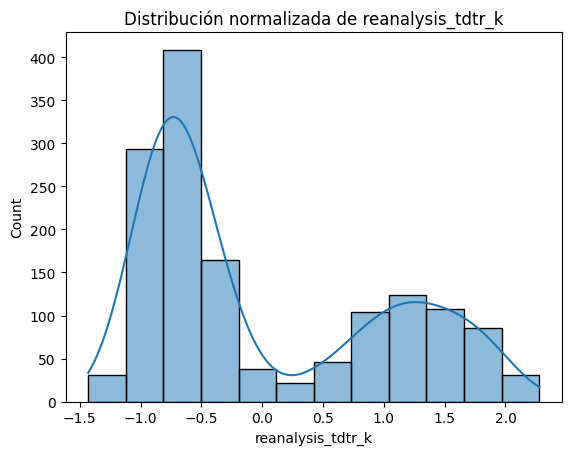

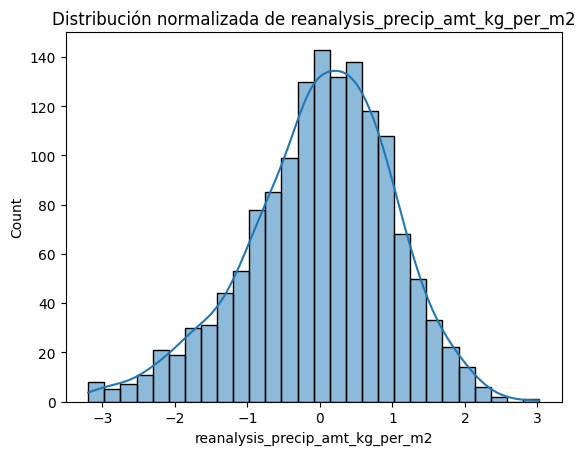

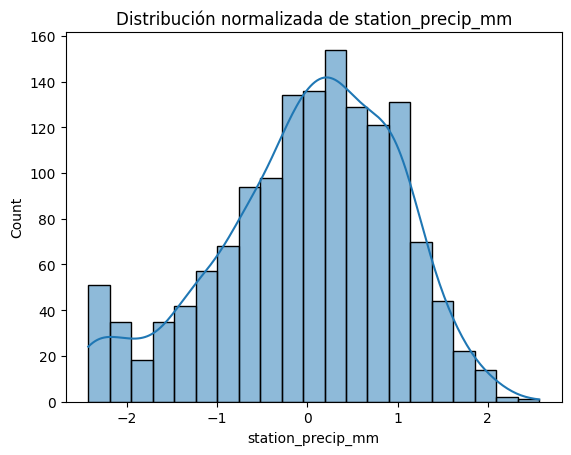

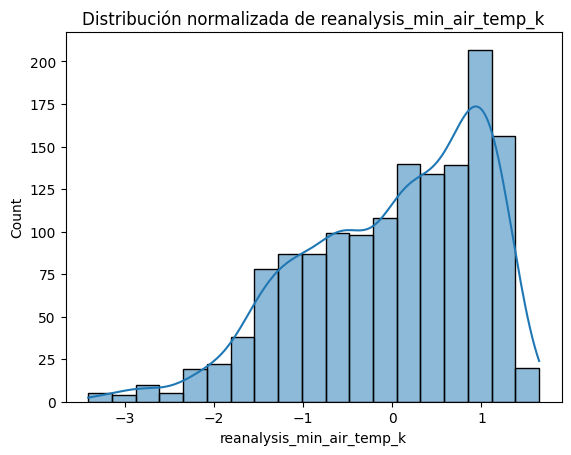

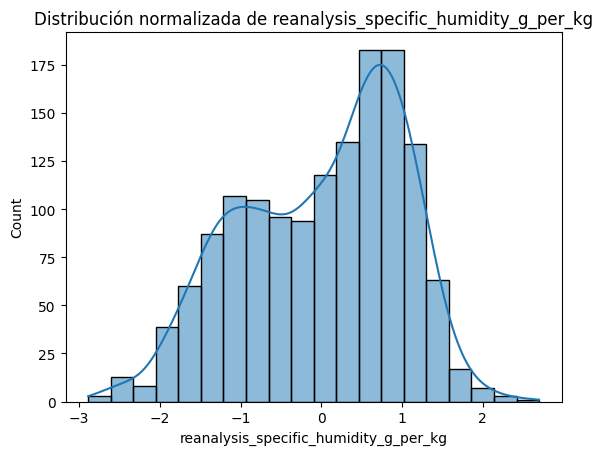

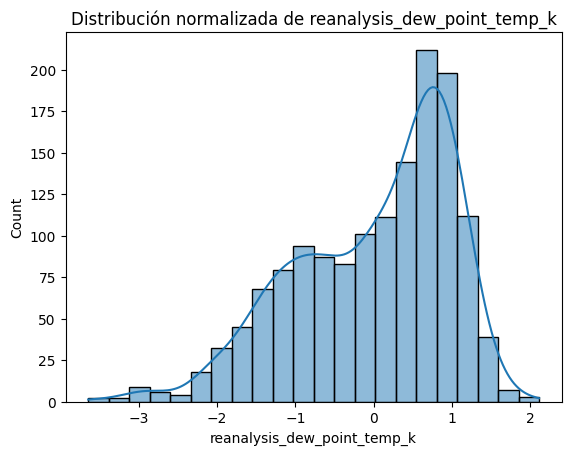

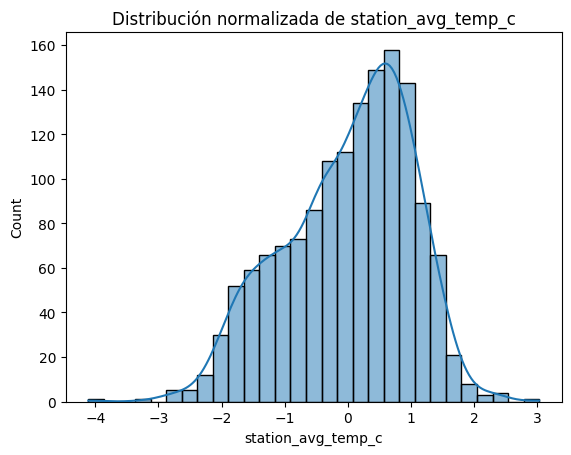

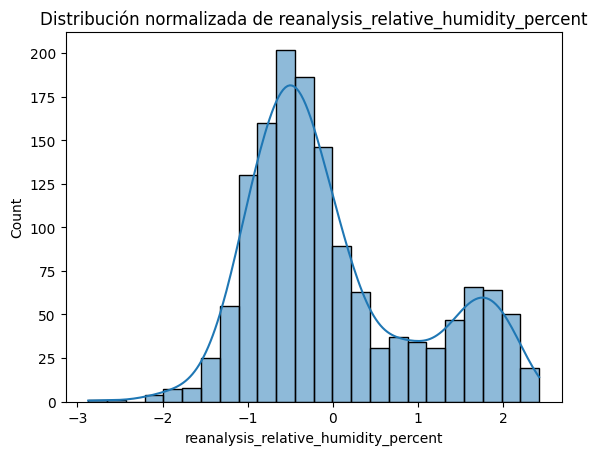

In [119]:
scaled_df = pd.DataFrame(X_train_SVR_escalado, columns=X_train_SVR.columns)
for col in vars_der + vars_izq:
    plt.figure()
    sns.histplot(scaled_df[col], kde=True)
    plt.title(f"Distribución normalizada de {col}")

Si comparamos los histogramas de nuestras variables transformadas y normalizadas con los histogramas iniciales, podes ver las distribuciones han cambiado y ahora tienen a una normal evitando sesgos fuertes hacia la izquierda o derecha.

In [49]:
from sklearn.svm import SVR
from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV

regressor_svr = SVR()
regressor_svr

#RANDOMIZEDSEARCH
param_dist = {"kernel": ["rbf", "linear"],
              "C": uniform(0.1, 10),
              "epsilon": uniform(0.001, 0.2),
              "gamma": ["scale", "auto"]}

rnd_regres_svr = RandomizedSearchCV(estimator = regressor_svr, param_distributions = param_dist,
                               n_iter = 100, cv = 4, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_svr.fit(X_train_SVR_escalado, y_train_SVR_transformado)

def report(results, n_top=5): # Función para mostrar resultados
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

report(rnd_regres_svr.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: -17.899 (std: 9.231)
Parameters: {'C': np.float64(9.020465551771133), 'epsilon': np.float64(0.12722772519945258), 'gamma': 'auto', 'kernel': 'rbf'}

Model with rank: 2
Mean validation score: -17.902 (std: 9.287)
Parameters: {'C': np.float64(9.104180571633304), 'epsilon': np.float64(0.1276202914546536), 'gamma': 'scale', 'kernel': 'rbf'}

Model with rank: 3
Mean validation score: -17.903 (std: 9.296)
Parameters: {'C': np.float64(8.873730719279553), 'epsilon': np.float64(0.1491537235508409), 'gamma': 'scale', 'kernel': 'rbf'}

Model with rank: 4
Mean validation score: -17.904 (std: 9.221)
Parameters: {'C': np.float64(9.182658859666537), 'epsilon': np.float64(0.04891237813339449), 'gamma': 'auto', 'kernel': 'rbf'}

Model with rank: 5
Mean validation score: -17.926 (std: 9.269)
Parameters: {'C': np.float64(8.272222002012159), 'epsilon': np.float64(0.11204016231989247), 'gamma': 'auto', 'kernel': 'rbf'}



In [50]:
rnd_regres_svr.best_params_

{'C': np.float64(9.020465551771133),
 'epsilon': np.float64(0.12722772519945258),
 'gamma': 'auto',
 'kernel': 'rbf'}

In [51]:
#GRIDSEARCH
from sklearn.model_selection import GridSearchCV

param_dist_GD_SVR = {"kernel": ["rbf"],
              "C": [5, 7, 9, 11, 13],
              "epsilon": [0.05, 0.1,0.15, 0.2, 0.25],
              "gamma": ["auto"]}

grid_regres_svr = GridSearchCV(estimator = regressor_svr, param_grid = param_dist_GD_SVR,cv = 4, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_svr.fit(X_train_SVR_escalado, y_train_SVR_transformado)

GridSearchCV(cv=4, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [5, 7, 9, 11, 13],
                         'epsilon': [0.05, 0.1, 0.15, 0.2, 0.25],
                         'gamma': ['auto'], 'kernel': ['rbf']},
             scoring='neg_mean_absolute_error')

In [52]:
grid_regres_svr.best_estimator_

SVR(C=13, epsilon=0.25, gamma='auto')

In [53]:
mae_SVR_CV = -grid_regres_svr.best_score_
print(f"MAE promedio de validación cruzada: {mae_SVR_CV:.4f}")

MAE promedio de validación cruzada: 17.8428


In [54]:
# choose the best
best_random = grid_regres_svr.best_estimator_
# fit and predict
y_pred_svr = best_random.predict(X_test_SVR_escalado)
y_pred_svr

array([ 9.51282075,  8.34323139,  5.30773806,  7.59641381,  9.70529892,
       10.62222504,  4.65451155, 16.45203095, 19.08591137, 18.94972114,
        8.33694626, 24.14804532, 16.59870234, 23.1853614 , 26.59334475,
       25.67035368, 21.45659069, 35.13987001, 30.80675411, 10.36332122,
       34.94460913, 26.81503341, 34.61125952, 40.1909326 , 34.24309459,
       21.27453021, 37.74302093, 34.09939393, 33.16339314, 31.82560695,
       29.74089624, 19.98847172, 11.75541261, 19.51748061, 14.58628286,
       15.78628526, 12.41498861, 16.5916802 , 17.60580031, 15.95742154,
       16.7515821 , 15.79397597, 17.48427681, 11.67644757, 10.43147042,
       14.99832195,  9.51083122,  1.38651761, 12.8295311 ,  9.0744739 ,
        2.82230909,  8.173205  ,  8.95980627, 11.5126462 , 15.91364911,
       14.18102473,  5.47691881,  8.68327992, 11.51994723, 11.70531419,
       14.74435047, 15.52357591, 26.32078292, 25.85862105, 27.75510816,
       26.59650614, 25.82413987, 31.5241878 , 31.69284171, 33.95

In [56]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred_svr) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred_svr < 0] = 0
res

array([10,  8,  5,  8, 10, 11,  5, 16, 19, 19,  8, 24, 17, 23, 27, 26, 21,
       35, 31, 10, 35, 27, 35, 40, 34, 21, 38, 34, 33, 32, 30, 20, 12, 20,
       15, 16, 12, 17, 18, 16, 17, 16, 17, 12, 10, 15, 10,  1, 13,  9,  3,
        8,  9, 12, 16, 14,  5,  9, 12, 12, 15, 16, 26, 26, 28, 27, 26, 32,
       32, 34, 34, 32, 30, 40, 39, 39, 42, 29, 38, 27, 18, 35, 35, 32, 30,
       37, 28, 41, 12, 16, 16, 15, 18, 12, 11, 12,  2, 12,  8,  5,  7, 10,
        7, 10, 12,  9,  2,  5,  9, 17, 17, 19, 13, 16, 23, 29, 19, 17, 24,
       32, 28, 37, 31, 29, 32, 34, 28, 38, 27, 27, 22, 36, 36, 21,  4, 16,
       11,  9, 21, 21, 22, 25, 13, 17, 18, 16, 12, 15,  9,  6,  6, 10, 14,
       12, 12, 10,  3, 11,  9, 15, 11,  7, 10, 19, 19, 18, 16, 19, 18, 26,
       21, 27, 30, 25, 23, 34, 40, 27, 32, 29, 27, 32, 22, 30, 34, 20, 35,
       21,  8, 38, 24, 29, 16, 18, 16, 21, 15, 17, 13, 10, 11, 15, 10,  5,
       15, 13, 11, 13, 11, 11, 12,  7,  5,  6, 13, 13, 19, 20, 22, 20, 16,
       18, 25, 27, 24, 27

In [57]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251029233538.csv


MAE TEST 27.6707

Obtuvimos un MAE TEST significamente peor que los antiores modelos, por lo cual haremos otra iteración amplicando los rangos para nuestro randomizedsearch y aumentando la cross-validation a cinco.

In [120]:
regressor_svr2 = SVR()
regressor_svr2

#RANDOMIZEDSEARCH
param_dist = {"kernel": ["rbf", "linear"],
              "C": uniform(1, 100),
              "epsilon": uniform(0.05, 0.4),
              "gamma": ["scale", "auto"]}

rnd_regres_svr2 = RandomizedSearchCV(estimator = regressor_svr2, param_distributions = param_dist,
                               n_iter = 150, cv = 5, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_svr2.fit(X_train_SVR_escalado, y_train_SVR_transformado)
report(rnd_regres_svr2.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: -18.418 (std: 10.907)
Parameters: {'C': np.float64(7.9361300875165455), 'epsilon': np.float64(0.09031120055097067), 'gamma': 'auto', 'kernel': 'rbf'}

Model with rank: 2
Mean validation score: -18.458 (std: 10.818)
Parameters: {'C': np.float64(11.789142699330444), 'epsilon': np.float64(0.0625716742746937), 'gamma': 'scale', 'kernel': 'rbf'}

Model with rank: 3
Mean validation score: -18.459 (std: 10.800)
Parameters: {'C': np.float64(12.005192452767677), 'epsilon': np.float64(0.14117406501677668), 'gamma': 'auto', 'kernel': 'rbf'}

Model with rank: 4
Mean validation score: -18.484 (std: 10.770)
Parameters: {'C': np.float64(12.959424593830171), 'epsilon': np.float64(0.335297914889198), 'gamma': 'scale', 'kernel': 'rbf'}

Model with rank: 5
Mean validation score: -18.489 (std: 10.789)
Parameters: {'C': np.float64(12.98653673336828), 'epsilon': np.float64(0.18504606856145117), 'gamma': 'scale', 'kernel': 'rbf'}



In [121]:
rnd_regres_svr2.best_params_

{'C': np.float64(7.9361300875165455),
 'epsilon': np.float64(0.09031120055097067),
 'gamma': 'auto',
 'kernel': 'rbf'}

In [123]:
#GRIDSEARCH
from sklearn.model_selection import GridSearchCV

param_dist_GD_GBR = {"kernel": ["rbf"],
              "C": [5, 7, 9, 11],
              "epsilon": [0.005, 0.01, 0.015, 0.02, 0.025],
              "gamma": ["auto"]}

grid_regres_svr2 = GridSearchCV(estimator = regressor_svr2, param_grid = param_dist_GD_GBR,cv = 5, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_svr2.fit(X_train_SVR_escalado, y_train_SVR_transformado)

GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [5, 7, 9, 11],
                         'epsilon': [0.005, 0.01, 0.015, 0.02, 0.025],
                         'gamma': ['auto'], 'kernel': ['rbf']},
             scoring='neg_mean_absolute_error')

In [114]:
grid_regres_svr2.best_estimator_

SVR(C=15, epsilon=0.5)

In [124]:
mae_SVR_CV2 = -grid_regres_svr2.best_score_
print(f"MAE promedio de validación cruzada: {mae_SVR_CV2:.4f}")

MAE promedio de validación cruzada: 18.3910


In [116]:
# choose the best
best_random = grid_regres_svr2.best_estimator_
# fit and predict
y_pred_svr2 = best_random.predict(X_test_SVR_escalado)
y_pred_svr2

array([ 9.23063209,  7.65190927,  5.17186201,  7.81755407,  9.75988537,
       10.84363233,  4.96712732, 16.53208553, 19.40546239, 18.96604566,
        8.24039707, 24.66983014, 15.96655538, 23.45636474, 26.22751908,
       25.7544503 , 20.22461587, 35.1410885 , 30.18383238,  9.67898217,
       34.70343524, 26.81238776, 34.44413795, 40.75572162, 34.17590199,
       21.54971755, 38.34868128, 34.75639156, 33.27518935, 32.33947695,
       30.25222452, 20.32068793, 11.79257719, 20.22368345, 14.7367446 ,
       15.76495125, 12.47782631, 17.04894327, 17.54760663, 16.64857043,
       16.92161292, 15.89942046, 17.16574117, 11.60423943, 10.17008662,
       14.9295203 ,  9.10217578,  0.40447567, 13.1213652 ,  8.56371362,
        2.48628016,  8.00462931,  8.95463587, 11.07540095, 15.58074719,
       13.33692646,  5.74137354,  8.75505808, 11.36992478, 11.68097987,
       15.04074603, 15.52564796, 26.39241709, 25.94474785, 27.76874463,
       26.43636851, 25.70206045, 31.571935  , 31.78659008, 33.91

In [125]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred_svr2) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred_svr2 < 0] = 0
res

array([ 9,  8,  5,  8, 10, 11,  5, 17, 19, 19,  8, 25, 16, 23, 26, 26, 20,
       35, 30, 10, 35, 27, 34, 41, 34, 22, 38, 35, 33, 32, 30, 20, 12, 20,
       15, 16, 12, 17, 18, 17, 17, 16, 17, 12, 10, 15,  9,  0, 13,  9,  2,
        8,  9, 11, 16, 13,  6,  9, 11, 12, 15, 16, 26, 26, 28, 26, 26, 32,
       32, 34, 34, 32, 30, 41, 39, 39, 42, 29, 38, 27, 18, 36, 35, 33, 30,
       37, 27, 42, 13, 16, 16, 16, 18, 12, 11, 12,  2, 12,  8,  5,  7, 10,
        6, 10, 13,  8,  2,  4,  9, 16, 16, 19, 12, 16, 23, 28, 19, 16, 24,
       33, 29, 37, 30, 28, 32, 34, 28, 38, 26, 27, 21, 37, 37, 20,  4, 16,
       11,  9, 21, 21, 22, 25, 14, 18, 18, 17, 12, 15,  8,  5,  6, 10, 14,
       12, 12, 10,  4, 11,  9, 15, 11,  6, 10, 19, 18, 17, 16, 18, 17, 26,
       21, 27, 30, 24, 22, 34, 39, 26, 32, 29, 27, 32, 22, 30, 33, 21, 36,
       21,  9, 38, 24, 29, 17, 19, 16, 21, 15, 18, 13,  9, 11, 15,  9,  5,
       15, 13, 11, 13, 11, 11, 12,  7,  5,  6, 14, 13, 19, 20, 22, 20, 16,
       18, 25, 27, 24, 27

In [126]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251030004459.csv


MAE TEST 27.6659

Ahora aplicaremos el algortimo KNN, el cual es sensible a datos no normalizados. Dado esto, normalizaremos todos nuestos datos excluyendo a nuestra variable objetivo total_cases. Aplicaremos un randomizedsearch en un rango amplio para ver que hiperparámetros nos sugiere, usaremos inicialmente 100 iteraciones y un cross-validation de cuatro. Luego, aplicaremos un gridsearch con valores cercanos para ver si encontramos mejores hiperparámetros para finalmente hacer la predicción y obetener nuestro MAE TEST.

In [81]:
# Algoritmo KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

X_train_KNN = train_mod[vars_importantes]
X_test_KNN = test_mod[vars_importantes]
y_train = train_mod["total_cases"]

X_train_KNN_escalado = X_train_KNN.copy()
X_test_KNN_escalado = X_test_KNN.copy()
y_train_KNN= y_train.copy()

scaler = StandardScaler()
X_train_KNN_escalado = scaler.fit_transform(X_train_KNN_escalado)
X_test_KNN_escalado = scaler.transform(X_test_KNN_escalado)

In [82]:
regressor_knn = KNeighborsRegressor()
regressor_knn

#RANDOMIZEDSEARCH
param_dist = {"n_neighbors": randint(2,20),
              "weights": ["uniform", "distance"],
              "p": [1, 2],
              "leaf_size": randint(5, 30)}

rnd_regres_knn = RandomizedSearchCV(estimator = regressor_knn, param_distributions = param_dist,
                               n_iter = 100, cv = 4, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_knn.fit(X_train_KNN_escalado, y_train_KNN)

def report(results, n_top=5): # Función para mostrar resultados
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

report(rnd_regres_knn.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: -19.409 (std: 8.849)
Parameters: {'leaf_size': 7, 'n_neighbors': 19, 'p': 2, 'weights': 'distance'}

Model with rank: 2
Mean validation score: -19.459 (std: 8.902)
Parameters: {'leaf_size': 15, 'n_neighbors': 18, 'p': 2, 'weights': 'distance'}

Model with rank: 3
Mean validation score: -19.493 (std: 8.878)
Parameters: {'leaf_size': 15, 'n_neighbors': 18, 'p': 2, 'weights': 'uniform'}

Model with rank: 3
Mean validation score: -19.493 (std: 8.878)
Parameters: {'leaf_size': 7, 'n_neighbors': 18, 'p': 2, 'weights': 'uniform'}

Model with rank: 5
Mean validation score: -19.506 (std: 9.136)
Parameters: {'leaf_size': 22, 'n_neighbors': 13, 'p': 2, 'weights': 'distance'}

Model with rank: 5
Mean validation score: -19.506 (std: 9.136)
Parameters: {'leaf_size': 16, 'n_neighbors': 13, 'p': 2, 'weights': 'distance'}



In [83]:
rnd_regres_knn.best_params_

{'leaf_size': 7, 'n_neighbors': 19, 'p': 2, 'weights': 'distance'}

In [85]:
#GRIDSEARCH
from sklearn.model_selection import GridSearchCV

param_dist_GD_KNN = {"n_neighbors": [6, 7, 8],
              "weights": ["distance"],
              "p": [2],
              "leaf_size": [5, 7, 9, 11]}

grid_regres_knn = GridSearchCV(estimator = regressor_knn, param_grid = param_dist_GD_KNN,cv = 5, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_knn.fit(X_train_KNN_escalado, y_train_KNN)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'leaf_size': [5, 7, 9, 11], 'n_neighbors': [6, 7, 8],
                         'p': [2], 'weights': ['distance']},
             scoring='neg_mean_absolute_error')

In [86]:
grid_regres_knn.best_estimator_

KNeighborsRegressor(leaf_size=5, n_neighbors=8, weights='distance')

In [87]:
mae_KNN_CV = -grid_regres_knn.best_score_
print(f"MAE promedio de validación cruzada: {mae_KNN_CV:.4f}")

MAE promedio de validación cruzada: 21.4832


In [88]:
# choose the best
best_random = grid_regres_knn.best_estimator_
# fit and predict
y_pred_knn = best_random.predict(X_test_KNN_escalado)
y_pred_knn

array([ 6.52679337,  5.44192649, 19.65829326, 12.96724484, 12.37768707,
       17.16977177, 10.45985566, 10.61852785, 15.45357705, 30.17971449,
       12.29504731, 38.64212035, 14.60246701, 21.4911365 , 30.49188893,
       33.35243841, 19.40445044, 61.2740625 , 55.42673623, 24.72038813,
       29.6767511 , 80.39179272, 42.58046521, 83.03875943, 29.19920945,
       31.67554636, 41.72064933, 31.68882085, 35.52714633, 79.95628671,
       41.06021773, 30.61933254, 22.48587449, 31.30538774, 17.587975  ,
       22.37380089, 16.29880129, 24.22691933, 28.87289549, 27.99830894,
       14.49761778, 17.43934003, 18.70167229, 19.51270351, 11.68529167,
       11.07761189, 19.03264809,  9.21451115, 16.35331802, 11.85961692,
       14.80900181, 11.91084187, 17.15910947, 12.25735481, 10.11125512,
        8.36544126, 12.25195717, 16.66932493, 30.86861592, 28.0733038 ,
       22.68440845, 13.55914888, 40.29858822, 41.84649638, 66.43204703,
       34.86302957, 26.61492609, 42.7632444 , 28.5794613 , 43.38

In [89]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred_knn) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred_knn < 0] = 0
res

array([ 7,  5, 20, 13, 12, 17, 10, 11, 15, 30, 12, 39, 15, 21, 30, 33, 19,
       61, 55, 25, 30, 80, 43, 83, 29, 32, 42, 32, 36, 80, 41, 31, 22, 31,
       18, 22, 16, 24, 29, 28, 14, 17, 19, 20, 12, 11, 19,  9, 16, 12, 15,
       12, 17, 12, 10,  8, 12, 17, 31, 28, 23, 14, 40, 42, 66, 35, 27, 43,
       29, 43, 32, 38, 45, 76, 30, 42, 36, 22, 48, 46, 22, 32, 44, 56, 28,
       50, 25, 93, 28, 41, 28, 31, 20, 18, 18, 17, 16, 18, 10, 10,  7, 11,
       12, 16, 17, 12,  9, 35, 18, 24, 58, 36, 56, 16, 36, 63, 42, 32, 24,
       44, 46, 59, 73, 27, 32, 52, 38, 83, 22, 30, 22, 30, 55, 20, 22, 31,
       23, 26, 23, 35, 20, 31, 15, 14, 18, 16, 12, 22, 15, 11, 19, 15, 16,
       14, 20, 13, 16,  5,  6, 25, 26, 19, 23, 57, 43, 63, 26, 37, 37, 96,
       17, 47, 53, 82, 58, 38, 70, 47, 38, 61, 47, 57, 37, 32, 45, 39, 47,
       32, 28, 97, 37, 45, 27, 37, 12, 28, 16, 24, 12, 14,  9, 16, 15,  7,
       14, 15, 17, 17, 15, 28,  7, 21,  7,  8, 14, 18, 22, 24, 28, 18, 29,
       20, 31, 51, 19, 35

In [90]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251030121102.csv


MAE TEST 27.0793

Si bien KNN nos entrega un MAE TEST mejor que Support Vector, sigue siendo significativamente peor que nuestors anteriores algoritmos. Realizaremos una segunda prueba para ver si obtenemos un mejor resultado aumentado el rango de n_neighbors y leaf_size. Además, aumentaremos las iteraciones a 300 y el cross-validation a cinco.

In [135]:
regressor_knn2 = KNeighborsRegressor()
regressor_knn2

#RANDOMIZEDSEARCH
param_dist = {"n_neighbors": randint(2,50),
              "weights": ["uniform", "distance"],
              "p": [1, 2],
              "leaf_size": randint(5, 50)}

rnd_regres_knn2 = RandomizedSearchCV(estimator = regressor_knn2, param_distributions = param_dist,
                               n_iter = 300, cv = 5, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_knn2.fit(X_train_KNN_escalado, y_train_KNN)
report(rnd_regres_knn2.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: -21.076 (std: 11.258)
Parameters: {'leaf_size': 18, 'n_neighbors': 22, 'p': 2, 'weights': 'distance'}

Model with rank: 2
Mean validation score: -21.090 (std: 11.223)
Parameters: {'leaf_size': 6, 'n_neighbors': 21, 'p': 2, 'weights': 'uniform'}

Model with rank: 3
Mean validation score: -21.094 (std: 11.254)
Parameters: {'leaf_size': 44, 'n_neighbors': 22, 'p': 2, 'weights': 'uniform'}

Model with rank: 3
Mean validation score: -21.094 (std: 11.254)
Parameters: {'leaf_size': 29, 'n_neighbors': 22, 'p': 2, 'weights': 'uniform'}

Model with rank: 3
Mean validation score: -21.094 (std: 11.254)
Parameters: {'leaf_size': 15, 'n_neighbors': 22, 'p': 2, 'weights': 'uniform'}



In [136]:
rnd_regres_knn2.best_params_

{'leaf_size': 18, 'n_neighbors': 22, 'p': 2, 'weights': 'distance'}

In [158]:
#GRIDSEARCH
from sklearn.model_selection import GridSearchCV

param_dist_GD_KNN = {"n_neighbors": [21, 22, 23],
              "weights": ["distance"],
              "p": [2],
              "leaf_size": [8, 12, 16, 20, 24]}

grid_regres_knn2 = GridSearchCV(estimator = regressor_knn2, param_grid = param_dist_GD_KNN,cv = 5, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_knn2.fit(X_train_KNN_escalado, y_train_KNN)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'leaf_size': [8, 12, 16, 20, 24],
                         'n_neighbors': [21, 22, 23], 'p': [2],
                         'weights': ['distance']},
             scoring='neg_mean_absolute_error')

In [159]:
grid_regres_knn2.best_estimator_

KNeighborsRegressor(leaf_size=8, n_neighbors=21, weights='distance')

In [160]:
mae_KNN_CV2 = -grid_regres_knn2.best_score_
print(f"MAE promedio de validación cruzada: {mae_KNN_CV2:.4f}")

MAE promedio de validación cruzada: 21.0724


In [161]:
# choose the best
best_random = grid_regres_knn2.best_estimator_
# fit and predict
y_pred_knn2 = best_random.predict(X_test_KNN_escalado)
y_pred_knn2

array([ 9.49603893,  9.48208197, 13.52435507, 12.47062474, 20.46511578,
       20.1263498 , 12.41670903, 18.1401917 , 29.36969874, 38.72330127,
       13.88623154, 41.91244148, 20.19670626, 25.88085891, 43.45775972,
       43.39082726, 24.02160228, 63.296572  , 62.13325894, 29.19447648,
       38.82387798, 62.35711469, 54.52453582, 55.3339395 , 66.46345615,
       43.21088531, 62.30347828, 30.24898763, 57.269804  , 56.6880038 ,
       71.29218535, 31.72424937, 37.08554948, 57.86995945, 26.86839369,
       19.43538746, 15.17043535, 22.92164866, 29.30074244, 33.96412987,
       18.39964561, 20.37086919, 16.91257562, 20.58183574, 11.9331489 ,
       14.82810125, 19.66341761, 12.8518555 , 20.98780943, 11.23654357,
       12.5625995 , 14.37939021, 18.56592152, 14.56996435, 14.26823712,
       14.70162407, 10.54529056, 14.60849967, 25.13208309, 23.24968447,
       22.01222268, 41.22625136, 43.99835835, 49.12372082, 57.752247  ,
       34.82116077, 26.02137644, 37.66774813, 23.36195849, 41.37

In [162]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred_knn2) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred_knn2 < 0] = 0
res

array([ 9,  9, 14, 12, 20, 20, 12, 18, 29, 39, 14, 42, 20, 26, 43, 43, 24,
       63, 62, 29, 39, 62, 55, 55, 66, 43, 62, 30, 57, 57, 71, 32, 37, 58,
       27, 19, 15, 23, 29, 34, 18, 20, 17, 21, 12, 15, 20, 13, 21, 11, 13,
       14, 19, 15, 14, 15, 11, 15, 25, 23, 22, 41, 44, 49, 58, 35, 26, 38,
       23, 41, 43, 55, 46, 51, 53, 39, 36, 32, 50, 41, 28, 38, 44, 81, 34,
       84, 35, 93, 20, 26, 15, 28, 22, 19, 18, 18, 13, 15, 19,  9, 10, 11,
       12, 14, 22, 16, 13, 24, 17, 41, 43, 41, 37, 18, 46, 61, 59, 29, 45,
       51, 47, 61, 66, 39, 40, 46, 37, 76, 28, 39, 39, 33, 62, 36, 28, 26,
       19, 24, 28, 29, 20, 30, 14, 17, 21, 20, 20, 20, 17, 14, 18, 14, 19,
       16, 18, 15, 11, 12,  9, 18, 27, 18, 20, 50, 38, 50, 26, 40, 39, 56,
       20, 43, 47, 64, 55, 49, 58, 44, 52, 46, 52, 38, 32, 39, 63, 31, 40,
       31, 27, 72, 32, 44, 22, 25, 21, 25, 17, 19, 16, 16, 13, 18, 15, 13,
       19, 17, 16, 17, 18, 18, 12, 17, 10, 12, 36, 21, 40, 21, 23, 25, 31,
       30, 49, 54, 41, 44

In [163]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251030122554.csv


MAE TEST 26.6250

Este último valor de MAE TEST es relativamente bueno y se acerca un poco más a los valores que estabamos obteniendo con nuestros algorítmos basados en árboles de decisión.

Por último, aplicaremos el algortimo LGBM (Light Gradient Boosting Machine), el cual se basa en árboles de decisión, por lo cual no es necesario realizar trasnformaciones o escalado a nuestras variables. Aplicaremos un randomizedsearch en un rango amplio para ver que hiperparámetros nos sugiere, usaremos inicialmente 100 iteraciones y un cross-validation de cuatro. Luego, aplicaremos un gridsearch con valores cercanos para ver si encontramos mejores hiperparámetros para finalmente hacer la predicción y obetener nuestro MAE TEST.

In [179]:
from lightgbm import LGBMRegressor

X_train_LGBM = train_mod[vars_importantes].copy()
X_test_LGBM = test_mod[vars_importantes].copy()
y_train_LGBM = train_mod["total_cases"].copy()

regressor_lgbm = LGBMRegressor(random_state = 42)
regressor_lgbm

#RANDOMIZEDSEARCH
param_dist = {"n_estimators": randint(50, 400),
              "learning_rate": uniform(0.01, 0.5),
              "max_depth": randint(5, 15),
              "subsample": uniform(0.7, 0.3),
              "colsample_bytree": uniform(0.7, 0.3),
              "num_leaves": randint(10, 50)}

rnd_regres_lgbm = RandomizedSearchCV(estimator = regressor_lgbm, param_distributions = param_dist,
                               n_iter = 100, cv = 4, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_lgbm.fit(X_train_LGBM, y_train_LGBM)

def report(results, n_top=5): # Función para mostrar resultados
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

report(rnd_regres_lgbm.cv_results_, n_top = 5)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3536
[LightGBM] [Info] Number of data points in the train set: 1456, number of used features: 16
[LightGBM] [Info] Start training from score 24.675137
Model with rank: 1
Mean validation score: -19.678 (std: 7.874)
Parameters: {'colsample_bytree': np.float64(0.7782680870025142), 'learning_rate': np.float64(0.017652270145192377), 'max_depth': 7, 'n_estimators': 145, 'num_leaves': 10, 'subsample': np.float64(0.8618132345200187)}

Model with rank: 2
Mean validation score: -19.802 (std: 7.373)
Parameters: {'colsample_bytree': np.float64(0.9273538331393107), 'learning_rate': np.float64(0.017196744314877936), 'max_depth': 9, 'n_estimators': 96, 'num_leaves': 39, 'subsample': np.float64(0.9566381752033022)}

Model with rank: 3
Mean validation score: -19.863 (std: 7.689)
Parameters: {'colsample_bytree': np.

In [180]:
rnd_regres_lgbm.best_params_

{'colsample_bytree': np.float64(0.7782680870025142),
 'learning_rate': np.float64(0.017652270145192377),
 'max_depth': 7,
 'n_estimators': 145,
 'num_leaves': 10,
 'subsample': np.float64(0.8618132345200187)}

In [182]:
#GRIDSEARCH
from sklearn.model_selection import GridSearchCV

param_dist_GD_LGBM = {"n_estimators": [120, 140, 160, 180],
              "learning_rate": [0.01, 0.015, 0.02, 0.025],
              "max_depth": [6, 7, 8],
              "subsample": [0.7, 0.8, 0.9],
              "colsample_bytree": [0.7, 0.8, 0.9],
              "num_leaves": [8, 10, 12, 14]}

grid_regres_lgbm = GridSearchCV(estimator = regressor_lgbm, param_grid = param_dist_GD_LGBM,cv = 4, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_lgbm.fit(X_train_LGBM, y_train_LGBM)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3536
[LightGBM] [Info] Number of data points in the train set: 1456, number of used features: 16
[LightGBM] [Info] Start training from score 24.675137


GridSearchCV(cv=4, estimator=LGBMRegressor(random_state=42), n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'learning_rate': [0.01, 0.015, 0.02, 0.025],
                         'max_depth': [6, 7, 8],
                         'n_estimators': [120, 140, 160, 180],
                         'num_leaves': [8, 10, 12, 14],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring='neg_mean_absolute_error')

In [183]:
grid_regres_lgbm.best_estimator_

LGBMRegressor(colsample_bytree=0.9, learning_rate=0.02, max_depth=6,
              n_estimators=180, num_leaves=8, random_state=42, subsample=0.7)

In [184]:
mae_LGBM_CV = -grid_regres_lgbm.best_score_
print(f"MAE promedio de validación cruzada: {mae_LGBM_CV:.4f}")

MAE promedio de validación cruzada: 19.4774


In [185]:
# choose the best
best_random = grid_regres_lgbm.best_estimator_
# fit and predict
y_pred_lgbm = best_random.predict(X_test_LGBM)
y_pred_lgbm

array([ 11.63908157,  12.2553449 ,  15.56958008,  17.32682376,
        14.3799166 ,  20.59578519,  13.3819883 ,  19.61371885,
        21.59420659,  21.98286488,  13.32616251,  22.88009378,
        20.58196276,  26.23240504,  54.8832498 ,  50.31410937,
        29.83149867,  46.84116731,  68.74647305,  69.476504  ,
        56.92369115,  37.24954678,  42.47617956,  89.94925995,
        41.65388498,  60.20481699,  50.93469303,  26.5043681 ,
        43.80986304,  39.93887179, 102.99271598,  27.20531422,
        55.77128762,  32.16038862,  19.10348832,  22.36838856,
        17.80360844,  25.95668468,  22.15988601,  28.57460551,
        17.65446937,  20.88423211,  21.04588954,  18.93793993,
        12.44103135,  16.96344627,  14.21093828,  10.7935732 ,
        13.86325626,  11.78488174,  11.71425187,  12.14259781,
        16.72840946,  12.50743439,  19.72775061,  19.73344046,
        14.88830635,  14.98535155,  14.89353479,  14.02401375,
        12.19908764,  18.99443796,  25.59872053,  26.82

In [186]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred_lgbm) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred_lgbm < 0] = 0
res

array([ 12,  12,  16,  17,  14,  21,  13,  20,  22,  22,  13,  23,  21,
        26,  55,  50,  30,  47,  69,  69,  57,  37,  42,  90,  42,  60,
        51,  27,  44,  40, 103,  27,  56,  32,  19,  22,  18,  26,  22,
        29,  18,  21,  21,  19,  12,  17,  14,  11,  14,  12,  12,  12,
        17,  13,  20,  20,  15,  15,  15,  14,  12,  19,  26,  27,  39,
        34,  34,  38,  36,  55,  43,  41,  48,  78,  48, 104,  38,  23,
        58,  66,  27,  42,  41,  33,  25,  32,  26,  40,  26,  22,  30,
        22,  26,  14,  17,  16,  17,  12,  11,  12,  13,  11,  12,  13,
        11,  15,  14,  17,  15,  62,  54,  32,  32,  40,  54,  47,  48,
        64,  43,  81,  69,  77,  73,  75,  58,  42,  44,  68,  62,  34,
        29,  49,  46,  29,  23,  23,  23,  17,  27,  57,  25,  27,  24,
        19,  22,  19,  17,  16,  18,  12,  11,  13,  12,  14,  14,  14,
        12,  18,  14,  18,  19,  17,  16,  47,  48,  50,  39,  46,  15,
        71,  63,  72,  55,  79,  57,  45,  58,  31,  36,  40,  4

In [187]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251030132944.csv


MAE TEST 27.0505

In [55]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform, randint

X_train_LGBM = train_mod[vars_importantes].copy()
X_test_LGBM = test_mod[vars_importantes].copy()
y_train_LGBM = train_mod["total_cases"].copy()

regressor_lgbm2 = LGBMRegressor(random_state = 42)
regressor_lgbm2

#RANDOMIZEDSEARCH
param_dist = {"n_estimators": randint(200, 450),
              "learning_rate": uniform(0.01, 0.5),
              "max_depth": randint(5, 15),
              "subsample": uniform(0.7, 0.3),
              "colsample_bytree": uniform(0.7, 0.3),
              "num_leaves": randint(10, 50)}

rnd_regres_lgbm2 = RandomizedSearchCV(estimator = regressor_lgbm2, param_distributions = param_dist,
                               n_iter = 200, cv = 3, scoring = "neg_mean_absolute_error", random_state= 42, n_jobs = -1)

# Fit the random search model
rnd_regres_lgbm2.fit(X_train_LGBM, y_train_LGBM)

def report(results, n_top=5): # Función para mostrar resultados
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

report(rnd_regres_lgbm2.cv_results_, n_top = 5)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3536
[LightGBM] [Info] Number of data points in the train set: 1456, number of used features: 16
[LightGBM] [Info] Start training from score 24.675137
Model with rank: 1
Mean validation score: -24.574 (std: 9.528)
Parameters: {'colsample_bytree': np.float64(0.889679286375859), 'learning_rate': np.float64(0.01654722829416682), 'max_depth': 9, 'n_estimators': 248, 'num_leaves': 16, 'subsample': np.float64(0.9926623947048268)}

Model with rank: 2
Mean validation score: -25.041 (std: 8.530)
Parameters: {'colsample_bytree': np.float64(0.8131857895726218), 'learning_rate': np.float64(0.01129751219182328), 'max_depth': 8, 'n_estimators': 200, 'num_leaves': 17, 'subsample': np.float64(0.9244779071150975)}

Model with rank: 3
Mean validation score: -25.086 (std: 9.356)
Parameters: {'colsample_bytree': np.fl

In [57]:
rnd_regres_lgbm2.best_params_

{'colsample_bytree': np.float64(0.889679286375859),
 'learning_rate': np.float64(0.01654722829416682),
 'max_depth': 9,
 'n_estimators': 248,
 'num_leaves': 16,
 'subsample': np.float64(0.9926623947048268)}

In [58]:
#GRIDSEARCH
from sklearn.model_selection import GridSearchCV

param_dist_GD_LGBM = {"n_estimators": [220, 240, 260, 280],
              "learning_rate": [0.01, 0.015, 0.02, 0.025],
              "max_depth": [8, 9, 10],
              "subsample": [0.8, 0.9, 1],
              "colsample_bytree": [0.7, 0.8, 0.9],
              "num_leaves": [12, 14, 16, 20]}

grid_regres_lgbm2 = GridSearchCV(estimator = regressor_lgbm2, param_grid = param_dist_GD_LGBM,cv = 3, scoring = "neg_mean_absolute_error", n_jobs = -1)
grid_regres_lgbm2.fit(X_train_LGBM, y_train_LGBM)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000519 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3536
[LightGBM] [Info] Number of data points in the train set: 1456, number of used features: 16
[LightGBM] [Info] Start training from score 24.675137


GridSearchCV(cv=3, estimator=LGBMRegressor(random_state=42), n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'learning_rate': [0.01, 0.015, 0.02, 0.025],
                         'max_depth': [8, 9, 10],
                         'n_estimators': [220, 240, 260, 280],
                         'num_leaves': [12, 14, 16, 20],
                         'subsample': [0.8, 0.9, 1]},
             scoring='neg_mean_absolute_error')

In [59]:
grid_regres_lgbm2.best_estimator_

LGBMRegressor(colsample_bytree=0.9, learning_rate=0.015, max_depth=10,
              n_estimators=280, num_leaves=12, random_state=42, subsample=0.8)

In [60]:
mae_LGBM_CV2 = -grid_regres_lgbm2.best_score_
print(f"MAE promedio de validación cruzada: {mae_LGBM_CV2:.4f}")

MAE promedio de validación cruzada: 24.0189


In [61]:
# choose the best
best_random = grid_regres_lgbm2.best_estimator_
# fit and predict
y_pred_lgbm2 = best_random.predict(X_test_LGBM)
y_pred_lgbm2

array([  9.44866185,  10.04564829,   7.84981041,  13.06023536,
        12.84689142,  12.91867382,  11.125825  ,  14.95899316,
        21.62882781,  25.13013135,  11.45156035,  25.25179604,
        17.46280837,  24.94955586,  60.25137392,  47.86263775,
        25.16412329,  46.14051497,  72.31045096,  67.14088136,
        56.6180323 ,  41.56669485,  48.14909517,  89.50776876,
        41.38267569,  40.65650084,  49.2001071 ,  24.27917365,
        39.32973922,  36.23281368,  92.94863142,  26.35407509,
        37.00413088,  29.60434417,  13.79825274,  24.85820837,
        17.78061647,  24.09007475,  25.7181964 ,  32.03962315,
        18.16073994,  25.39286061,  21.29633143,  20.7467663 ,
        13.26613964,  17.93401564,  11.28450083,   9.01835298,
        12.38873669,   8.26012377,   9.52816277,   9.97693695,
        16.15239543,  11.92859236,  17.79044198,  18.17568794,
        12.48891557,  11.20060807,  12.9457545 ,  13.92001015,
        17.50887846,  17.25721191,  26.86338406,  25.54

In [62]:
# EJEMPLO: Redondear el resultado y convertirlo a entero
y = np.rint(y_pred_lgbm2) # round
y = y.astype(int) # cast to int
res = np.hstack(y)

# EJEMPLO: Cambiar valores negativos a cero
res[y_pred_lgbm2 < 0] = 0
res

array([  9,  10,   8,  13,  13,  13,  11,  15,  22,  25,  11,  25,  17,
        25,  60,  48,  25,  46,  72,  67,  57,  42,  48,  90,  41,  41,
        49,  24,  39,  36,  93,  26,  37,  30,  14,  25,  18,  24,  26,
        32,  18,  25,  21,  21,  13,  18,  11,   9,  12,   8,  10,  10,
        16,  12,  18,  18,  12,  11,  13,  14,  18,  17,  27,  26,  45,
        29,  33,  33,  32,  53,  42,  46,  47,  85,  65, 107,  32,  16,
        58,  64,  20,  50,  45,  28,  20,  28,  21,  41,  29,  24,  30,
        26,  26,  14,  17,  20,  21,  10,   8,  10,  10,   9,   9,  12,
        11,  15,  12,  18,  13,  64,  48,  34,  40,  45,  51,  49,  56,
        67,  43,  92,  74,  79,  69,  64,  51,  25,  36,  78,  54,  25,
        37,  48,  47,  35,  19,  18,  25,  19,  26,  53,  27,  26,  24,
        19,  22,  19,  15,  16,  16,  11,   9,  11,  10,  13,  14,  11,
         8,  19,  10,  17,  19,  15,  15,  56,  55,  53,  42,  50,  17,
        78,  50,  78,  55,  78,  56,  42,  39,  31,  31,  31,  4

In [63]:
download_predictions(test, res)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20251031173545.csv


MAE TEST 26.9760

---
# Conclusiones
---

Entre los distintos algoritmos que evaluamos a lo largo de este trabajo, Random Forest se quedó con el primer lugar al comparar en desempeño de todos nuestros modelos, obteniendo un MAE TEST de 26,0697, seguido por Gradient Boosting con un MAE TEST de 26,3197. Analizando los resultados obtenidos, nos podemos dar cuenta que los algoritmos basados en árboles de decisión son capaces de modelar con mejor presición relaciones no lineales y datasets con ruido. En el caso de Random Forest, su estructura de ensamble (entrena múltiples árboles sobre subconjuntos aleatorios de datos) le permite reducir la varianza y mantener una buena presición ante presencia de outliers o ruido, junto a esto, sus hiperparámetros como profundidad de 14 (moderada), número de estimadores 90 (moderado) y muestreo interno (bootstrap = True) permitió obtener buenos resultados a pesar de la complejidad del problema. Por otro lado, Gradient Boosting presentó un rendimiento parecido al de Random Forest gracias a su estructura de árboles secuenciales, los cuales van corrigiendo el error de los árboles anteriores, y también a sus hiperparámetros como tasa de aprendizaje (learning_rate) y número de estimadores alto. En el caso de Light Gradient Boosting Machine, si bien también está basado en árboles de desición, no se obtuvo un buen rendimiento probablemente debido a los hiperparámetros obtenidos y por limitaciones de tiempo que impidieron la realización de más pruebas para buscar mejores resultados. Para los algoritmos de KNN y Support Vector, se obtuvieron rendimientos más bajos que en los algoritmos basados en árboles debido a limitaciones estructurales como la sensibilidad al ruido.


| Modelo | MAE test (DrivenData) | MAE validación | Algoritmo | Hiperparámetros | Descripción
| --- | --- | --- | --- | --- | --- |
| regressor_rf | 26,4111 | 17,3732 | Random Forest | bootstrap = True, max_feature = 1.0, criterion = absolute_error, max_depth = 12, min_samples_leaf = 26, min_samples_split = 25, n_estimators = 25 | Tratamiendo de valores nulos. Transformaciones y normalización no aplica para este tipo de algoritmo
| regressor_rf2 | 26,5409 | 20,8531 | Random Forest | bootstrap = False, max_feature = log2, criterion = absolute_error, max_depth = 14, min_samples_leaf = 27, min_samples_split = 26, n_estimators = 64 | Tratamiendo de valores nulos. Transformaciones y normalización no aplica para este tipo de algoritmo
| regressor_rf2 | 26,1034 | 28,2412 | Random Forest | bootstrap = True, max_feature = sqrt, criterion = squared_error, max_depth = 12, min_samples_leaf = 29, min_samples_split = 25, n_estimators = 55 | Tratamiendo de valores nulos. Transformaciones y normalización no aplica para este tipo de algoritmo
| regressor_rf2 | 26,0697 | 28,7437| Random Forest | bootstrap = True, max_feature = sqrt, criterion = squared_error, max_depth = 14, min_samples_leaf = 29, min_samples_split = 23, n_estimators = 90 | Tratamiendo de valores nulos. Transformaciones y normalización no aplica para este tipo de algoritmo
| regressor_gbr | 26,3197 | 18,2983 | Gradient Boosting | max_feature = sqrt, criterion = squared_error, max_depth = 15, learning_rate = 0,05, loss = absolute_error, min_samples_split = 23, n_estimators = 200 | Tratamiendo de valores nulos. Transformaciones y normalización no aplica para este tipo de algoritmo
| regressor_gbr2 | 26,5769 | 20,548 | Gradient Boosting | max_feature = log2, criterion = friedman_mse, max_depth = 5, learning_rate = 0,035, loss = absolute_error, min_samples_split = 15, n_estimators = 350 | Tratamiendo de valores nulos. Transformaciones y normalización no aplica para este tipo de algoritmo
| regressor_gbr2 | 26,6995 | 20,7943 | Gradient Boosting | max_feature = sqrt, criterion = friedman_mse, max_depth = 20, learning_rate = 0,01, loss = absolute_error, min_samples_split = 17, n_estimators = 250 | Tratamiendo de valores nulos. Transformaciones y normalización no aplica para este tipo de algoritmo
| regressor_svr | 27,6707 | 17,8428 | Support Vector | kernel = rbf, C = 13, epsilon = 0,25, gamma = auto | Tratamiendo de valores nulos. Transformaciones logarítmicas. Transformaciones cuadráticas. Normalización de datos
| regressor_svr2 | 27,6659 | 18,3910 | Support Vector | kernel = rbf, C = 15, epsilon = 0,5, gamma = auto | Tratamiendo de valores nulos. Transformaciones logarítmicas. Transformaciones cuadráticas. Normalización de datos
| regressor_knn | 27,0793 | 21,4832 | KNN | n_neighbors = 8, weights = distance, p = 2,leaf_size = 5 | Tratamiendo de valores nulos. Normalización de datos
| regressor_knn2 | 26,6250 | 21,0724 | KNN | n_neighbors = 21, weights = distance, p = 2,leaf_size = 8 | Tratamiendo de valores nulos. Normalización de datos
| regressor_lgmb | 27,0505 | 19,4774 | Light Gradient Boosting Machine | n_estimators = 180, learning_rate = 0,02, max_depth = 6, subsample = 0,7, colsample_bytree = 0,9, num_leaves = 8 | Tratamiendo de valores nulos. Transformaciones y normalización no aplica para este tipo de algoritmo
| regressor_lgmb2 | 26,9760 | 24,0189 | Light Gradient Boosting Machine | n_estimators = 280, learning_rate = 0,015, max_depth = 10, subsample = 0,8, colsample_bytree = 0,9, num_leaves = 12 | Tratamiendo de valores nulos. Transformaciones y normalización no aplica para este tipo de algoritmo


**Modelo final elegido**
* Nombre/Identificador: regressor_rf2
* MAE test (DrivenData): 26,0697
* MAE validación: 28,7437
* Algoritmo ML: Random Forest
* Hiperparámetros: bootstrap = True, max_feature = sqrt, criterion = squared_error, max_depth = 14, min_samples_leaf = 29, min_samples_split = 23, n_estimators = 90
* Lista de características: reanalysis_min_air_temp_k, weekofyear, ndvi_sw, station_max_temp_c, reanalysis_tdtr_k, reanalysis_specific_humidity_g_per_kg, ndvi_nw, reanalysis__dew_point_temp_k, reanalysis_precip_amt_kg_per_m2, ndvi_se, ndvi_ne, station_precip_mm, station_avg_temp_c, reanalysis_avg_temp_k, reanalysis_relative_humidity_percent, reanalysis_air_temp_k
* Resumen del dataset (transformaciones aplicadas, etc.): Tratamiento de valores nulos. No se eliminaron outliers. Transformaciones y normalización no aplica para este tipo de algoritmo

---
# Competición
---

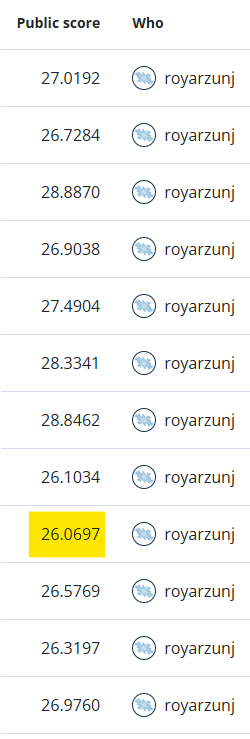